In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Python_Daria/dataset.zip"
extract_path = "/content/drive/MyDrive/Python_Daria/final_project"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
os.listdir(extract_path)

['13. Final project', 'clean_sales_data.csv']

In [ ]:
data_path = "/content/drive/MyDrive/Python_Daria/final_project/13. Final project"

os.listdir(data_path)

['countries.csv', 'products.csv', 'events.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
events = pd.read_csv(f"{data_path}/events.csv")
products = pd.read_csv(f"{data_path}/products.csv")
countries = pd.read_csv(f"{data_path}/countries.csv")

In [ ]:
print("events:", events.shape)
print("products:", products.shape)
print("countries:", countries.shape)

events: (1330, 10)
products: (12, 2)
countries: (249, 5)


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
print("EVENTS")
events.info()

print("\nPRODUCTS")
products.info()

print("\nCOUNTRIES")
countries.info()

EVENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(

In [ ]:
print("events:")
print(events.columns.tolist())

print("\nproducts:")
print(products.columns.tolist())

print("\ncountries:")
print(countries.columns.tolist())

events:
['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code', 'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost']

products:
['id', 'item_type']

countries:
['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']


In [ ]:
print("EVENTS")
display(events.nunique().sort_values())

print("\nPRODUCTS")
display(products.nunique().sort_values())

print("\nCOUNTRIES")
display(countries.nunique().sort_values())

EVENTS


,0
Sales Channel,3
Order Priority,6
Product ID,12
Unit Price,12
Unit Cost,12
Country Code,45
Order Date,1049
Ship Date,1070
Units Sold,1239
Order ID,1330



PRODUCTS


,0
id,12
item_type,12



COUNTRIES


,0
region,5
sub-region,17
alpha-2,248
name,249
alpha-3,249


In [ ]:
print("Product IDs:")
print(products["id"].tolist())

print("\nCountry codes in events:")
print(events["Country Code"].dropna().unique()[:20])

print("\nProduct IDs in events:")
print(events["Product ID"].unique())

Product IDs:
[2103, 7940, 2455, 1270, 8681, 4594, 5988, 7331, 8875, 8293, 8969, 3127]

Country codes in events:
['NOR' 'SRB' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO' 'GBR' 'SVN'
 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT']

Product IDs in events:
[2103 7940 2455 1270 8681 4594 5988 7331 8875 8293 8969 3127]


In [ ]:
def missing_report(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })

    return result[result["missing_count"] > 0].sort_values(
        "missing_percent",
        ascending=False
    )

print("EVENTS")
display(missing_report(events))

print("COUNTRIES")
display(missing_report(countries))

print("PRODUCTS")
display(missing_report(products))

EVENTS


,missing_count,missing_percent
Country Code,82,6.165414
Units Sold,2,0.150376


COUNTRIES


,missing_count,missing_percent
alpha-2,1,0.401606
region,1,0.401606
sub-region,1,0.401606


PRODUCTS


,missing_count,missing_percent


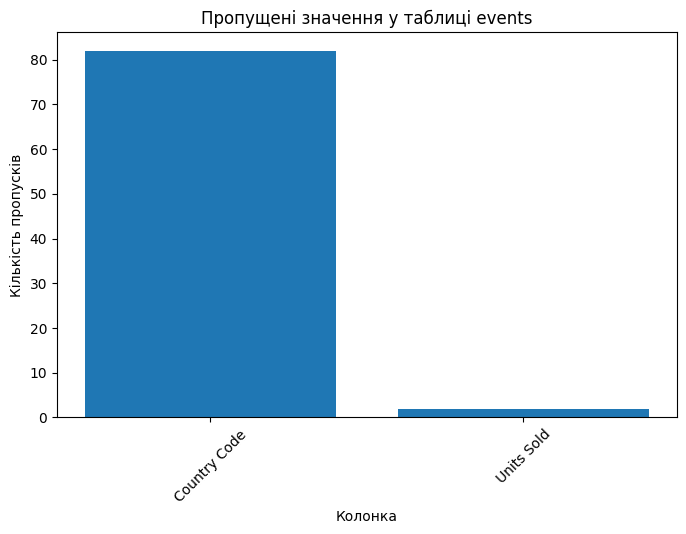

In [ ]:
missing_events = events.isna().sum()
missing_events = missing_events[missing_events > 0]

plt.figure(figsize=(8, 5))

plt.bar(missing_events.index, missing_events.values)

plt.title("Пропущені значення у таблиці events")
plt.xlabel("Колонка")
plt.ylabel("Кількість пропусків")
plt.xticks(rotation=45)

plt.show()

### Аналіз пропущених значень

У таблиці `events` виявлено пропуски у колонках `Country Code` та `Units Sold`. Найбільша кількість пропусків припадає на `Country Code` — 82 значення, що становить близько 6,2% усіх записів.

У `Units Sold` відсутні лише 2 значення, тому їх частка є незначною.

У таблиці `products` пропущених значень немає. У таблиці `countries` є по одному пропущеному значенню у колонках `alpha-2`, `region` та `sub-region`.

Пропуски потребують окремого опрацювання. Видалення 82 записів із відсутнім `Country Code` може призвести до втрати значної частини інформації, тому перед прийняттям рішення необхідно перевірити, чи можна відновити ці значення або використати записи без географічної деталізації для інших видів аналізу.

In [ ]:
events.dropna()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
5,103450715,3/15/2015,4/18/2015,H,SVK,8681,Online,2220.0,651.21,524.96
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


In [ ]:
events[events["Country Code"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
48,128766906,2/13/2011,3/28/2011,C,NaN,7940,Offline,3844.0,668.27,502.54
50,129169023,6/8/2012,7/18/2012,M,NaN,1270,Offline,2839.0,47.45,31.79
58,133276450,1/27/2016,3/15/2016,H,NaN,3127,Online,8318.0,81.73,56.67
66,139949357,7/1/2014,7/14/2014,H,NaN,5988,Online,2980.0,154.06,90.93
83,150293242,5/19/2015,6/21/2015,H,NaN,8681,Offline,3965.0,651.21,524.96


In [ ]:
events[events["Country Code"].isna()][
    ["Order Date", "Ship Date", "Order Priority", "Product ID",
     "Sales Channel", "Units Sold", "Unit Price", "Unit Cost"]
]

,Order Date,Ship Date,Order Priority,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,7/18/2014,8/11/2014,M,7940,Online,4693.0,668.27,502.54
13,1/1/2014,1/5/2014,M,7331,Online,7076.0,255.28,159.42
26,1/24/2015,3/2/2015,H,4594,Offline,6813.0,9.33,6.92
29,6/2/2011,7/1/2011,L,8969,Offline,2013.0,152.58,97.44
43,5/24/2017,7/9/2017,C,7331,Online,5762.0,255.28,159.42
48,2/13/2011,3/28/2011,C,7940,Offline,3844.0,668.27,502.54
50,6/8/2012,7/18/2012,M,1270,Offline,2839.0,47.45,31.79
58,1/27/2016,3/15/2016,H,3127,Online,8318.0,81.73,56.67
66,7/1/2014,7/14/2014,H,5988,Online,2980.0,154.06,90.93
83,5/19/2015,6/21/2015,H,8681,Offline,3965.0,651.21,524.96


In [ ]:
events[events["Units Sold"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67


In [ ]:
events[events["Units Sold"].isna()][
    ["Order ID", "Product ID", "Unit Price", "Unit Cost", "Sales Channel"]
]

,Order ID,Product ID,Unit Price,Unit Cost,Sales Channel
183,217165648,8875,421.89,364.69,Offline
319,309655511,3127,81.73,56.67,Offline


In [ ]:
print("Дублікати events:", events.duplicated().sum())
print("Дублікати products:", products.duplicated().sum())
print("Дублікати countries:", countries.duplicated().sum())

Дублікати events: 0
Дублікати products: 0
Дублікати countries: 0


In [ ]:
events[events.duplicated(keep=False)].sort_values("Order ID")

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
def find_whitespace(df):
    for column in df.select_dtypes(include="object").columns:
        mask = df[column].astype("string").str.strip().ne(df[column].astype("string"))

        if mask.any():
            print(f"\n{column}:")
            print(df.loc[mask, column].unique())

print("EVENTS")
find_whitespace(events)

print("\nPRODUCTS")
find_whitespace(products)

print("\nCOUNTRIES")
find_whitespace(countries)

EVENTS

Order Priority:
[' C' 'M ']

PRODUCTS

COUNTRIES


In [ ]:
print("Sales Channel:")
print(events["Sales Channel"].value_counts(dropna=False))

print("\nOrder Priority:")
print(events["Order Priority"].value_counts(dropna=False))

Sales Channel:
Sales Channel
Offline    667
Online     660
online       3
Name: count, dtype: int64

Order Priority:
Order Priority
M     353
H     335
L     334
C     305
 C      2
M       1
Name: count, dtype: int64


In [ ]:
order_dates = pd.to_datetime(events["Order Date"], errors="coerce")
ship_dates = pd.to_datetime(events["Ship Date"], errors="coerce")

print("Некоректних Order Date:", order_dates.isna().sum())
print("Некоректних Ship Date:", ship_dates.isna().sum())

Некоректних Order Date: 0
Некоректних Ship Date: 0


In [ ]:
invalid_dates = events[ship_dates < order_dates]

print("Замовлень з Ship Date раніше Order Date:", len(invalid_dates))

Замовлень з Ship Date раніше Order Date: 0


In [ ]:
events[
    ["Units Sold", "Unit Price", "Unit Cost"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,1328.0,4952.201807,2905.198996,2.00,2356.75,4962.00,7459.50,9999.00
Unit Price,1330.0,264.893541,217.323460,9.33,81.73,154.06,437.20,668.27
Unit Cost,1330.0,187.246812,176.158873,6.92,35.84,97.44,263.33,524.96


In [ ]:
numeric_columns = ["Units Sold", "Unit Price", "Unit Cost"]

for column in numeric_columns:
    print(f"\n{column}")
    print("Від'ємних значень:", (events[column] < 0).sum())
    print("Нульових значень:", (events[column] == 0).sum())


Units Sold
Від'ємних значень: 0
Нульових значень: 0

Unit Price
Від'ємних значень: 0
Нульових значень: 0

Unit Cost
Від'ємних значень: 0
Нульових значень: 0


In [ ]:
price_anomalies = events[
    events["Unit Price"] < events["Unit Cost"]
]

print("Записів, де Unit Price < Unit Cost:", len(price_anomalies))

Записів, де Unit Price < Unit Cost: 0


In [ ]:
events["Order ID"].duplicated()

,Order ID
0,False
1,False
2,False
3,False
4,False
...,...
1325,False
1326,False
1327,False
1328,False


In [ ]:
order_items = events.groupby("Order ID")["Product ID"].nunique()

order_items.describe()

,Product ID
count,1330.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
# ==========================================
# ПОВНИЙ DATA QUALITY AUDIT
# ==========================================

print("=" * 70)
print("1. РОЗМІР ТА СТРУКТУРА ТАБЛИЦЬ")
print("=" * 70)

print(f"events:    {events.shape}")
print(f"products:  {products.shape}")
print(f"countries: {countries.shape}")


# ==========================================
# 2. ТИПИ ДАНИХ
# ==========================================

print("\n" + "=" * 70)
print("2. ТИПИ ДАНИХ")
print("=" * 70)

print("\n--- EVENTS ---")
print(events.dtypes)

print("\n--- PRODUCTS ---")
print(products.dtypes)

print("\n--- COUNTRIES ---")
print(countries.dtypes)


# ==========================================
# 3. ПРОПУЩЕНІ ЗНАЧЕННЯ
# ==========================================

print("\n" + "=" * 70)
print("3. ПРОПУЩЕНІ ЗНАЧЕННЯ")
print("=" * 70)

def missing_report(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2)
    })
    return result[result["missing_count"] > 0].sort_values(
        "missing_percent",
        ascending=False
    )

print("\n--- EVENTS ---")
display(missing_report(events))

print("\n--- PRODUCTS ---")
display(missing_report(products))

print("\n--- COUNTRIES ---")
display(missing_report(countries))


# ==========================================
# 4. ДУБЛІКАТИ
# ==========================================

print("\n" + "=" * 70)
print("4. ДУБЛІКАТИ")
print("=" * 70)

print(f"events:    {events.duplicated().sum()}")
print(f"products:  {products.duplicated().sum()}")
print(f"countries: {countries.duplicated().sum()}")


# ==========================================
# 5. УНІКАЛЬНІ ЗНАЧЕННЯ
# ==========================================

print("\n" + "=" * 70)
print("5. УНІКАЛЬНІ ЗНАЧЕННЯ")
print("=" * 70)

print("\n--- EVENTS ---")

for column in events.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(events[column].value_counts(dropna=False))


print("\n--- PRODUCTS ---")

for column in products.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(products[column].value_counts(dropna=False))


# ==========================================
# 6. ЗАЙВІ ПРОБІЛИ
# ==========================================

print("\n" + "=" * 70)
print("6. ПЕРЕВІРКА ЗАЙВИХ ПРОБІЛІВ")
print("=" * 70)

def find_whitespace(df, table_name):
    found = False

    print(f"\n--- {table_name} ---")

    for column in df.select_dtypes(include="object").columns:

        mask = (
            df[column].astype("string").str.strip()
            != df[column].astype("string")
        )

        if mask.any():
            found = True
            print(f"{column}:")
            print(df.loc[mask, column].unique())

    if not found:
        print("Зайвих пробілів не знайдено.")


find_whitespace(events, "EVENTS")
find_whitespace(products, "PRODUCTS")
find_whitespace(countries, "COUNTRIES")


# ==========================================
# 7. ПЕРЕВІРКА ДАТ
# ==========================================

print("\n" + "=" * 70)
print("7. ПЕРЕВІРКА ДАТ")
print("=" * 70)

order_dates = pd.to_datetime(events["Order Date"], errors="coerce")
ship_dates = pd.to_datetime(events["Ship Date"], errors="coerce")

print("Некоректних Order Date:", order_dates.isna().sum())
print("Некоректних Ship Date:", ship_dates.isna().sum())

invalid_dates = events[ship_dates < order_dates]

print(
    "Ship Date раніше Order Date:",
    len(invalid_dates)
)


# ==========================================
# 8. ЧИСЛОВІ АНОМАЛІЇ
# ==========================================

print("\n" + "=" * 70)
print("8. ЧИСЛОВІ АНОМАЛІЇ")
print("=" * 70)

numeric_columns = [
    "Units Sold",
    "Unit Price",
    "Unit Cost"
]

print("\n--- DESCRIBE ---")
display(events[numeric_columns].describe().T)


for column in numeric_columns:

    print(f"\n{column}")

    print(
        "Від'ємних:",
        (events[column] < 0).sum()
    )

    print(
        "Нульових:",
        (events[column] == 0).sum()
    )


# ==========================================
# 9. UNIT PRICE < UNIT COST
# ==========================================

print("\n" + "=" * 70)
print("9. ПЕРЕВІРКА ЦІНИ ТА СОБІВАРТОСТІ")
print("=" * 70)

price_anomalies = events[
    events["Unit Price"] < events["Unit Cost"]
]

print(
    "Записів, де Unit Price < Unit Cost:",
    len(price_anomalies)
)

if len(price_anomalies) > 0:
    print("\nПриклади:")
    display(
        price_anomalies[
            [
                "Order ID",
                "Product ID",
                "Unit Price",
                "Unit Cost"
            ]
        ].head(10)
    )


# ==========================================
# 10. ПРОПУЩЕНИЙ COUNTRY CODE
# ==========================================

print("\n" + "=" * 70)
print("10. ПРОПУЩЕНИЙ COUNTRY CODE")
print("=" * 70)

missing_country = events[
    events["Country Code"].isna()
]

print(
    "Кількість записів:",
    len(missing_country)
)

if len(missing_country) > 0:
    display(
        missing_country[
            [
                "Order ID",
                "Order Date",
                "Ship Date",
                "Order Priority",
                "Product ID",
                "Sales Channel",
                "Units Sold",
                "Unit Price",
                "Unit Cost"
            ]
        ].head(20)
    )


# ==========================================
# 11. ПРОПУЩЕНИЙ UNITS SOLD
# ==========================================

print("\n" + "=" * 70)
print("11. ПРОПУЩЕНИЙ UNITS SOLD")
print("=" * 70)

missing_units = events[
    events["Units Sold"].isna()
]

print(
    "Кількість записів:",
    len(missing_units)
)

if len(missing_units) > 0:
    display(missing_units)


# ==========================================
# 12. КЛЮЧІ ТА JOIN
# ==========================================

print("\n" + "=" * 70)
print("12. ПЕРЕВІРКА КЛЮЧІВ")
print("=" * 70)

missing_products = (
    set(events["Product ID"])
    - set(products["id"])
)

missing_countries = (
    set(events["Country Code"].dropna())
    - set(countries["alpha-3"])
)

print(
    "Product ID без відповідності:",
    missing_products
)

print(
    "Country Code без відповідності:",
    missing_countries
)

print(
    "Унікальних Product ID у products:",
    products["id"].nunique()
)

print(
    "Унікальних alpha-3 у countries:",
    countries["alpha-3"].nunique()
)


# ==========================================
# 13. СТАТИСТИКА ЗАМОВЛЕНЬ
# ==========================================

print("\n" + "=" * 70)
print("13. СТАТИСТИКА ЗАМОВЛЕНЬ")
print("=" * 70)

print(
    "Усього записів:",
    len(events)
)

print(
    "Унікальних Order ID:",
    events["Order ID"].nunique()
)

print(
    "Унікальних Product ID:",
    events["Product ID"].nunique()
)

print(
    "Унікальних Country Code:",
    events["Country Code"].nunique()
)


# ==========================================
# 14. ORDER ITEMS
# ==========================================

print("\n" + "=" * 70)
print("14. КІЛЬКІСТЬ ТОВАРІВ У ЗАМОВЛЕННЯХ")
print("=" * 70)

order_items = (
    events.groupby("Order ID")["Product ID"]
    .nunique()
)

display(order_items.describe())


# ==========================================
# КІНЕЦЬ AUDIT
# ==========================================

print("\n" + "=" * 70)
print("AUDIT ЗАВЕРШЕНО")
print("=" * 70)

1. РОЗМІР ТА СТРУКТУРА ТАБЛИЦЬ
events:    (1330, 10)
products:  (12, 2)
countries: (249, 5)

2. ТИПИ ДАНИХ

--- EVENTS ---
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

--- PRODUCTS ---
id            int64
item_type    object
dtype: object

--- COUNTRIES ---
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object

3. ПРОПУЩЕНІ ЗНАЧЕННЯ

--- EVENTS ---


,missing_count,missing_percent
Country Code,82,6.17
Units Sold,2,0.15



--- PRODUCTS ---


,missing_count,missing_percent



--- COUNTRIES ---


...


11. ПРОПУЩЕНИЙ UNITS SOLD
Кількість записів: 2


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67



12. ПЕРЕВІРКА КЛЮЧІВ
Product ID без відповідності: set()
Country Code без відповідності: set()
Унікальних Product ID у products: 12
Унікальних alpha-3 у countries: 249

13. СТАТИСТИКА ЗАМОВЛЕНЬ
Усього записів: 1330
Унікальних Order ID: 1330
Унікальних Product ID: 12
Унікальних Country Code: 45

14. КІЛЬКІСТЬ ТОВАРІВ У ЗАМОВЛЕННЯХ


,Product ID
count,1330.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0



AUDIT ЗАВЕРШЕНО


| Проблема                       |           Результат | Рішення                     |
| ------------------------------ | ------------------: | --------------------------- |
| `Country Code` пропуски        |   82 / 1330 = 6.17% | замінити на `"Unknown"`     |
| `Units Sold` пропуски          |    2 / 1330 = 0.15% | видалити 2 записи           |
| Дублікати                      |                   0 | нічого не робимо            |
| Зайві пробіли                  |    `Order Priority` | прибрати                    |
| Різний регістр                 | `Online` / `online` | привести до єдиного формату |
| Дати `object`                  |           2 колонки | перевести в `datetime`      |
| Некоректні дати                |                   0 | нічого не робимо            |
| `Ship Date < Order Date`       |                   0 | логіка дат коректна         |
| Негативні числа                |                   0 | нічого не робимо            |
| Нульові числа                  |                   0 | нічого не робимо            |
| `Unit Price < Unit Cost`       |                   0 | аномалій немає              |
| Product ID без відповідності   |                   0 | JOIN без проблем            |
| Country Code без відповідності |                   0 | JOIN без проблем            |


In [ ]:
events_clean = events.copy()
products_clean = products.copy()
countries_clean = countries.copy()

In [ ]:
# Прибираємо зайві пробіли та уніфікуємо регістр
for column in ["Order Priority", "Sales Channel"]:
    events_clean[column] = (
        events_clean[column]
        .astype("string")
        .str.strip()
    )

events_clean["Order Priority"] = events_clean["Order Priority"].str.upper()
events_clean["Sales Channel"] = events_clean["Sales Channel"].str.capitalize()

In [ ]:
print(events_clean["Order Priority"].value_counts())
print()
print(events_clean["Sales Channel"].value_counts())

Order Priority
M    354
H    335
L    334
C    307
Name: count, dtype: Int64

Sales Channel
Offline    667
Online     663
Name: count, dtype: Int64


In [ ]:
events_clean["Order Date"] = pd.to_datetime(
    events_clean["Order Date"]
)

events_clean["Ship Date"] = pd.to_datetime(
    events_clean["Ship Date"]
)

In [ ]:
events_clean[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
events_clean["Country Code"] = (
    events_clean["Country Code"]
    .fillna("Unknown")
)

In [ ]:
events_clean = events_clean.dropna(
    subset=["Units Sold"]
).copy()

In [ ]:
events_clean["Units Sold"].isna().sum()

np.int64(0)

In [ ]:
print("Початкова кількість записів:", len(events))
print("Кількість після очищення:", len(events_clean))
print("Видалено записів:", len(events) - len(events_clean))

print("\nПропущені значення:")
display(
    events_clean.isna().sum()
    .sort_values(ascending=False)
)

Початкова кількість записів: 1330
Кількість після очищення: 1328
Видалено записів: 2

Пропущені значення:


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
print("Дублікати:", events_clean.duplicated().sum())

print(
    "Некоректних дат:",
    (
        events_clean["Order Date"].isna().sum()
        + events_clean["Ship Date"].isna().sum()
    )
)

print(
    "Ship Date раніше Order Date:",
    (
        events_clean["Ship Date"] < events_clean["Order Date"]
    ).sum()
)

print(
    "Негативних Units Sold:",
    (events_clean["Units Sold"] < 0).sum()
)

print(
    "Негативних Unit Price:",
    (events_clean["Unit Price"] < 0).sum()
)

print(
    "Негативних Unit Cost:",
    (events_clean["Unit Cost"] < 0).sum()
)

Дублікати: 0
Некоректних дат: 0
Ship Date раніше Order Date: 0
Негативних Units Sold: 0
Негативних Unit Price: 0
Негативних Unit Cost: 0


In [ ]:
countries_clean[["alpha-2", "region", "sub-region"]] = (
    countries_clean[["alpha-2", "region", "sub-region"]]
    .fillna("Unknown")
)

In [ ]:
print("EVENTS")
print(events_clean.shape)
print("Пропуски:", events_clean.isna().sum().sum())
print("Дублікати:", events_clean.duplicated().sum())

print("\nPRODUCTS")
print(products_clean.shape)
print("Пропуски:", products_clean.isna().sum().sum())
print("Дублікати:", products_clean.duplicated().sum())

print("\nCOUNTRIES")
print(countries_clean.shape)
print("Пропуски:", countries_clean.isna().sum().sum())
print("Дублікати:", countries_clean.duplicated().sum())

EVENTS
(1328, 10)
Пропуски: 0
Дублікати: 0

PRODUCTS
(12, 2)
Пропуски: 0
Дублікати: 0

COUNTRIES
(249, 5)
Пропуски: 0
Дублікати: 0


## Висновок Data Cleaning

Під час перевірки якості даних було виявлено декілька проблем, які потребували очищення.

У таблиці `events` було виявлено 82 пропущених значення у `Country Code` (6,17%) та 2 пропущених значення у `Units Sold` (0,15%). Пропущені значення `Country Code` було замінено на категорію `Unknown`, оскільки відсутню країну неможливо достовірно відновити з наявних даних. Це дозволяє зберегти відповідні записи для загального фінансового аналізу та окремо враховувати їх у географічному аналізі.

Два записи з відсутнім `Units Sold` було видалено, оскільки цей показник є необхідним для розрахунку виручки, собівартості та прибутку, а достовірний спосіб його відновлення відсутній. Частка таких записів становить лише 0,15%, тому їх видалення практично не впливає на загальну структуру датасету.

Також було усунуто зайві пробіли у значеннях `Order Priority` та уніфіковано написання категорій у `Sales Channel`, зокрема значення `online` було приведено до єдиного формату `Online`.

Колонки `Order Date` та `Ship Date` було перетворено з текстового типу у формат `datetime`, що необхідно для подальшого аналізу часової динаміки та тривалості відвантаження.

Перевірка показала відсутність повних дублікатів, негативних або нульових значень у ключових числових показниках. Також не виявлено випадків, коли дата відвантаження передує даті замовлення, або коли собівартість товару перевищує його ціну.

У таблиці `countries` один запис мав пропуски у додаткових географічних характеристиках. Оскільки ключ `alpha-3` заповнений, запис було збережено, а відсутні описові значення замінено на `Unknown`.

Після очищення дані готові до об'єднання в єдиний датафрейм та подальшого бізнес-аналізу.

In [ ]:
df = events_clean.merge(
    products_clean,
    left_on="Product ID",
    right_on="id",
    how="left"
)

In [ ]:
df = df.merge(
    countries_clean,
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
)

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
df = df.drop(
    columns=["id", "alpha-2", "alpha-3"]
)

In [ ]:
df = df.rename(columns={
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Order Priority": "order_priority",
    "Country Code": "country_code",
    "Product ID": "product_id",
    "Sales Channel": "sales_channel",
    "Units Sold": "units_sold",
    "Unit Price": "unit_price",
    "Unit Cost": "unit_cost",
    "item_type": "product_category",
    "name": "country",
    "region": "region",
    "sub-region": "sub_region"
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1328 non-null   int64         
 1   order_date        1328 non-null   datetime64[ns]
 2   ship_date         1328 non-null   datetime64[ns]
 3   order_priority    1328 non-null   string        
 4   country_code      1328 non-null   object        
 5   product_id        1328 non-null   int64         
 6   sales_channel     1328 non-null   string        
 7   units_sold        1328 non-null   float64       
 8   unit_price        1328 non-null   float64       
 9   unit_cost         1328 non-null   float64       
 10  product_category  1328 non-null   object        
 11  country           1246 non-null   object        
 12  region            1246 non-null   object        
 13  sub_region        1246 non-null   object        
dtypes: datetime64[ns](2), fl

In [ ]:
print("Кількість рядків після JOIN:", len(df))
print("Кількість колонок:", len(df.columns))

Кількість рядків після JOIN: 1328
Кількість колонок: 14


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
sub_region,82
region,82
country,82
ship_date,0
order_id,0
order_date,0
product_id,0
country_code,0
order_priority,0
sales_channel,0


In [ ]:
df[["country", "region", "sub_region"]] = (
    df[["country", "region", "sub_region"]].fillna("Unknown")
)

df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
product_id,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0


In [ ]:
print("Розмір:", df.shape)
print("Пропуски:", df.isna().sum().sum())
print("Дублікати:", df.duplicated().sum())

Розмір: (1328, 14)
Пропуски: 0
Дублікати: 0


In [ ]:
df["revenue"] = df["units_sold"] * df["unit_price"]

df["cost"] = df["units_sold"] * df["unit_cost"]

df["profit"] = df["revenue"] - df["cost"]

In [ ]:
df[
    [
        "units_sold",
        "unit_price",
        "unit_cost",
        "revenue",
        "cost",
        "profit"
    ]
].head()

,units_sold,unit_price,unit_cost,revenue,cost,profit
0,650.0,205.70,117.11,133705.00,76121.50,57583.50
1,1993.0,205.70,117.11,409960.10,233400.23,176559.87
2,4693.0,668.27,502.54,3136191.11,2358420.22,777770.89
3,1171.0,109.28,35.84,127966.88,41968.64,85998.24
4,7648.0,47.45,31.79,362897.60,243129.92,119767.68


In [ ]:
df["shipping_days"] = (
    df["ship_date"] - df["order_date"]
).dt.days

In [ ]:
df["shipping_days"].describe()

,shipping_days
count,1328.000000
mean,24.786898
std,14.586041
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


In [ ]:
print(
    "Від'ємних shipping_days:",
    (df["shipping_days"] < 0).sum()
)

Від'ємних shipping_days: 0


In [ ]:
df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

df["day_of_week"] = df["order_date"].dt.day_name()

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region,revenue,cost,profit,shipping_days,year,month,month_name,day_of_week
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10,2014,10,October,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0,2016,8,August,Thursday
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown,3136191.11,2358420.22,777770.89,24,2014,7,July,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31,2017,5,May,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38,2012,8,August,Saturday


In [ ]:
print("Розмір фінального датафрейму:", df.shape)
print("\nКолонки:")
print(df.columns.tolist())

Розмір фінального датафрейму: (1328, 22)

Колонки:
['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code', 'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost', 'product_category', 'country', 'region', 'sub_region', 'revenue', 'cost', 'profit', 'shipping_days', 'year', 'month', 'month_name', 'day_of_week']


In [ ]:
clean_path = "/content/drive/MyDrive/Python_Daria/final_project/clean_sales_data.csv"

df.to_csv(
    clean_path,
    index=False
)

print(f"Файл збережено: {clean_path}")

Файл збережено: /content/drive/MyDrive/Python_Daria/final_project/clean_sales_data.csv


In [ ]:
total_orders = df["order_id"].nunique()

total_units = df["units_sold"].sum()

total_revenue = df["revenue"].sum()

total_cost = df["cost"].sum()

total_profit = df["profit"].sum()

profit_margin = total_profit / total_revenue * 100

total_countries = df["country_code"].nunique()

total_regions = df["region"].nunique()

total_categories = df["product_category"].nunique()

online_share = (
    (df["sales_channel"] == "Online").mean() * 100
)

offline_share = (
    (df["sales_channel"] == "Offline").mean() * 100
)

avg_order_revenue = df.groupby("order_id")["revenue"].sum().mean()

avg_units_per_order = df.groupby("order_id")["units_sold"].sum().mean()

avg_shipping_days = df["shipping_days"].mean()

In [ ]:
kpi = pd.Series({
    "Total orders": total_orders,
    "Total units sold": total_units,
    "Total revenue": total_revenue,
    "Total cost": total_cost,
    "Total profit": total_profit,
    "Profit margin (%)": profit_margin,
    "Countries covered": total_countries,
    "Regions covered": total_regions,
    "Product categories": total_categories,
    "Online share (%)": online_share,
    "Offline share (%)": offline_share,
    "Average order revenue": avg_order_revenue,
    "Average units per order": avg_units_per_order,
    "Average shipping time (days)": avg_shipping_days
})

kpi

,0
Total orders,1.328000e+03
Total units sold,6.576524e+06
Total revenue,1.702129e+09
Total cost,1.200695e+09
Total profit,5.014345e+08
Profit margin (%),2.945924e+01
Countries covered,4.600000e+01
Regions covered,3.000000e+00
Product categories,1.200000e+01
Online share (%),4.992470e+01


In [ ]:
kpi.round(2)

,0
Total orders,1.328000e+03
Total units sold,6.576524e+06
Total revenue,1.702129e+09
Total cost,1.200695e+09
Total profit,5.014345e+08
Profit margin (%),2.946000e+01
Countries covered,4.600000e+01
Regions covered,3.000000e+00
Product categories,1.200000e+01
Online share (%),4.992000e+01


In [ ]:
kpi_formatted = kpi.copy()

kpi_formatted["Total orders"] = f"{total_orders:,}"
kpi_formatted["Total units sold"] = f"{total_units:,.0f}"
kpi_formatted["Total revenue"] = f"${total_revenue:,.2f}"
kpi_formatted["Total cost"] = f"${total_cost:,.2f}"
kpi_formatted["Total profit"] = f"${total_profit:,.2f}"
kpi_formatted["Profit margin (%)"] = f"{profit_margin:.2f}%"
kpi_formatted["Countries covered"] = f"{total_countries}"
kpi_formatted["Regions covered"] = f"{total_regions}"
kpi_formatted["Product categories"] = f"{total_categories}"
kpi_formatted["Online share (%)"] = f"{online_share:.2f}%"
kpi_formatted["Offline share (%)"] = f"{offline_share:.2f}%"
kpi_formatted["Average order revenue"] = f"${avg_order_revenue:,.2f}"
kpi_formatted["Average units per order"] = f"{avg_units_per_order:,.2f}"
kpi_formatted["Average shipping time (days)"] = f"{avg_shipping_days:.2f}"

kpi_formatted

/tmp/ipykernel_1762/51998719.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1,328' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  kpi_formatted["Total orders"] = f"{total_orders:,}"


,0
Total orders,"1,328"
Total units sold,"6,576,524"
Total revenue,"$1,702,129,408.21"
Total cost,"$1,200,694,949.21"
Total profit,"$501,434,459.00"
Profit margin (%),29.46%
Countries covered,46
Regions covered,3
Product categories,12
Online share (%),49.92%


In [ ]:
category_analysis = (
    df.groupby("product_category")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_analysis["profit_margin"] = (
    category_analysis["profit"] / category_analysis["revenue"] * 100
)

category_analysis.round(2)

,orders,units_sold,revenue,cost,profit,profit_margin
product_category,,,,,,
Office Supplies,123,617641.0,4.022140e+08,3.242368e+08,77977176.25,19.39
Household,97,440249.0,2.942052e+08,2.212427e+08,72962466.77,24.80
Cosmetics,114,533291.0,2.331548e+08,1.404315e+08,92723306.17,39.77
Meat,110,530380.0,2.237620e+08,1.934243e+08,30337736.00,13.56
Baby Food,112,562706.0,1.436476e+08,8.970659e+07,53940997.16,37.55
Cereal,103,465685.0,9.579140e+07,5.453637e+07,41255034.15,43.07
Vegetables,114,582544.0,8.974673e+07,5.297073e+07,36776002.72,40.98
Snacks,103,490160.0,7.478861e+07,4.776119e+07,27027422.40,36.14
Clothes,105,591385.0,6.462655e+07,2.119524e+07,43431314.40,67.20


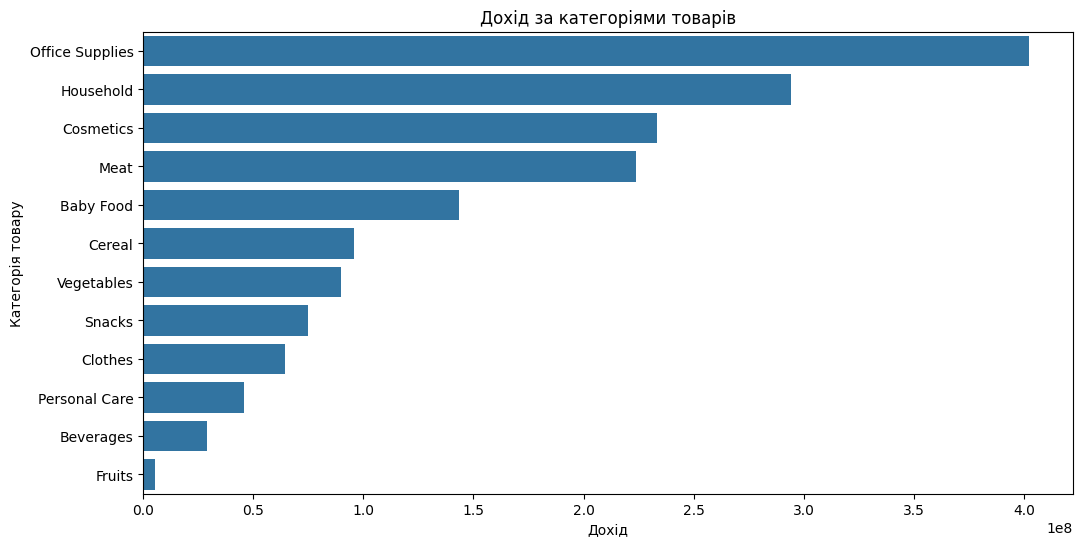

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_revenue = (
    category_analysis
    .sort_values("revenue", ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_revenue,
    x="revenue",
    y="product_category"
)

plt.title("Дохід за категоріями товарів")
plt.xlabel("Дохід")
plt.ylabel("Категорія товару")
plt.show()

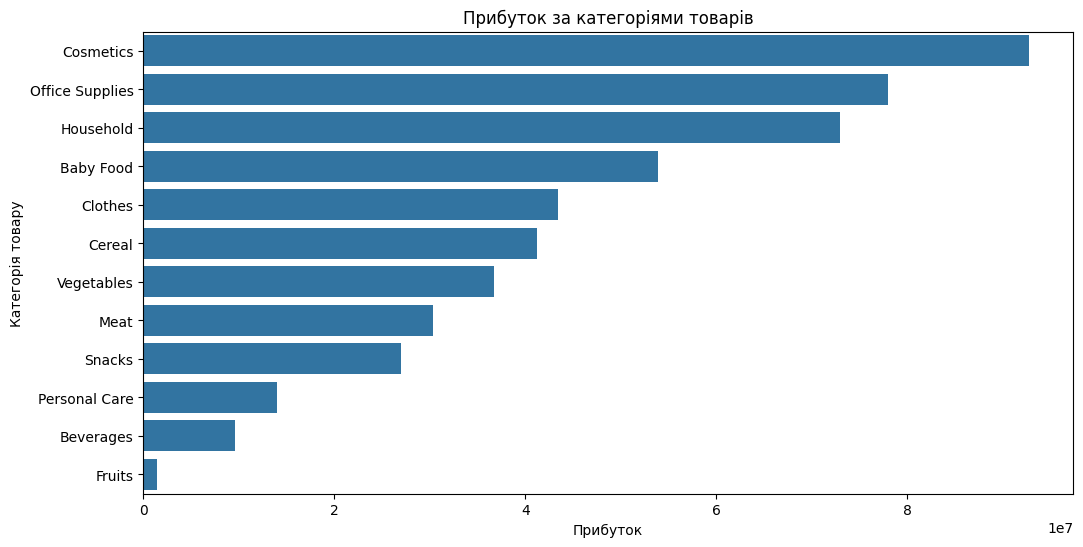

In [ ]:
category_profit = (
    category_analysis
    .sort_values("profit", ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_profit,
    x="profit",
    y="product_category"
)

plt.title("Прибуток за категоріями товарів")
plt.xlabel("Прибуток")
plt.ylabel("Категорія товару")
plt.show()

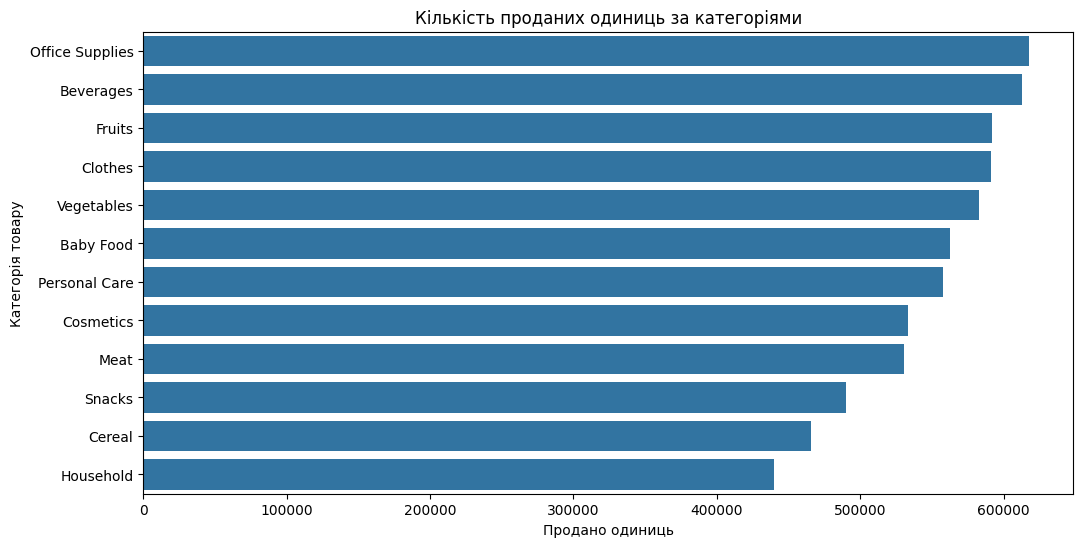

In [ ]:
category_units = (
    category_analysis
    .sort_values("units_sold", ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_units,
    x="units_sold",
    y="product_category"
)

plt.title("Кількість проданих одиниць за категоріями")
plt.xlabel("Продано одиниць")
plt.ylabel("Категорія товару")
plt.show()

,orders,units_sold,revenue,cost,profit,profit_margin
product_category,,,,,,
Office Supplies,123,617641.0,4.022140e+08,3.242368e+08,77977176.25,19.39
Household,97,440249.0,2.942052e+08,2.212427e+08,72962466.77,24.80
Cosmetics,114,533291.0,2.331548e+08,1.404315e+08,92723306.17,39.77
Meat,110,530380.0,2.237620e+08,1.934243e+08,30337736.00,13.56
Baby Food,112,562706.0,1.436476e+08,8.970659e+07,53940997.16,37.55
Cereal,103,465685.0,9.579140e+07,5.453637e+07,41255034.15,43.07
Vegetables,114,582544.0,8.974673e+07,5.297073e+07,36776002.72,40.98
Snacks,103,490160.0,7.478861e+07,4.776119e+07,27027422.40,36.14
Clothes,105,591385.0,6.462655e+07,2.119524e+07,43431314.40,67.20


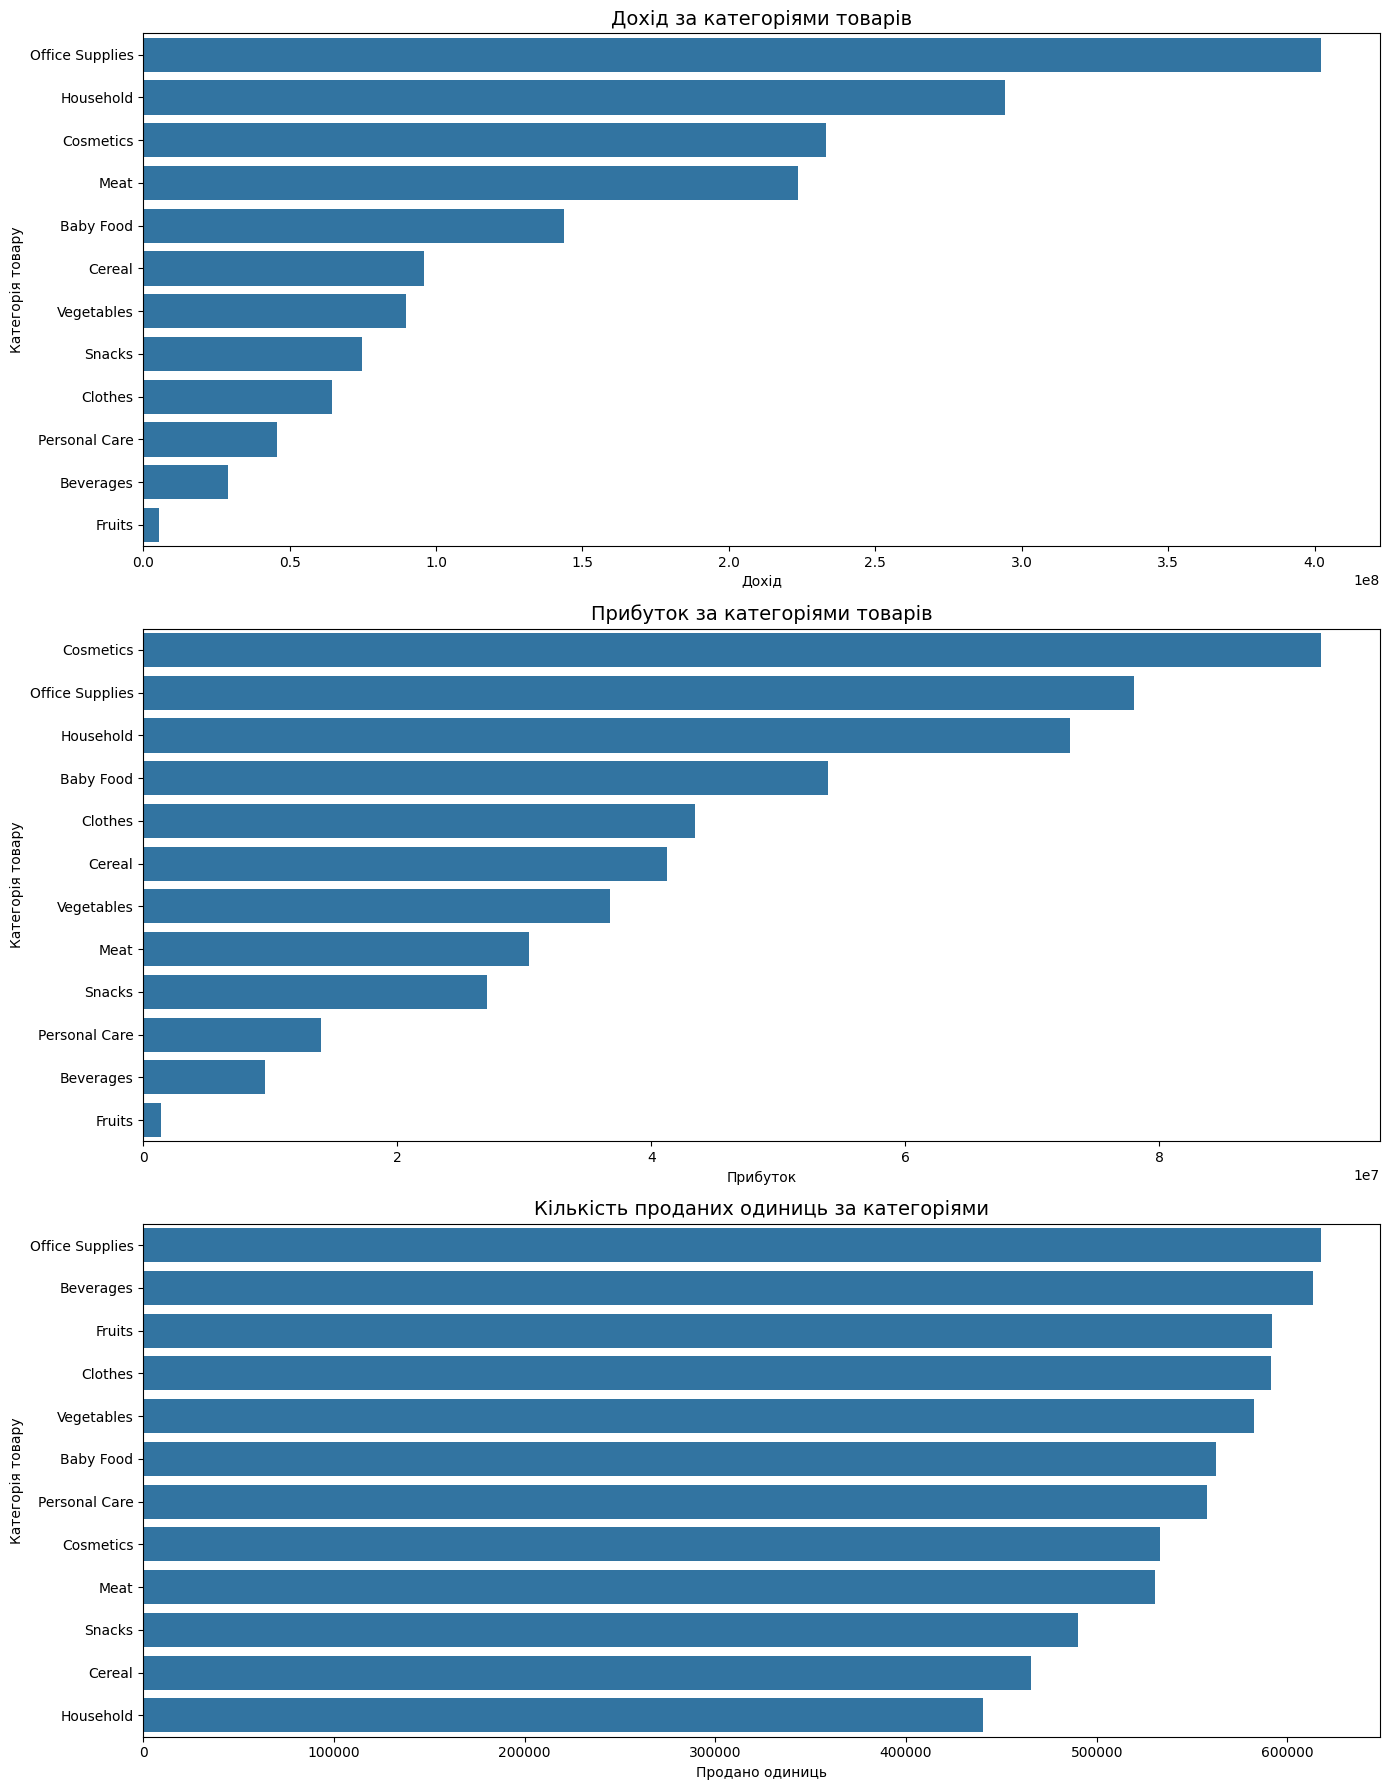

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Аналіз категорій
category_analysis = (
    df.groupby("product_category")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_analysis["profit_margin"] = (
    category_analysis["profit"] / category_analysis["revenue"] * 100
)

# Виводимо таблицю
display(category_analysis.round(2))

# Підготовка даних для графіків
category_revenue = (
    category_analysis
    .sort_values("revenue", ascending=False)
    .reset_index()
)

category_profit = (
    category_analysis
    .sort_values("profit", ascending=False)
    .reset_index()
)

category_units = (
    category_analysis
    .sort_values("units_sold", ascending=False)
    .reset_index()
)

# Створюємо 3 графіки
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Revenue
sns.barplot(
    data=category_revenue,
    x="revenue",
    y="product_category",
    ax=axes[0]
)
axes[0].set_title("Дохід за категоріями товарів", fontsize=14)
axes[0].set_xlabel("Дохід")
axes[0].set_ylabel("Категорія товару")

# Profit
sns.barplot(
    data=category_profit,
    x="profit",
    y="product_category",
    ax=axes[1]
)
axes[1].set_title("Прибуток за категоріями товарів", fontsize=14)
axes[1].set_xlabel("Прибуток")
axes[1].set_ylabel("Категорія товару")

# Units sold
sns.barplot(
    data=category_units,
    x="units_sold",
    y="product_category",
    ax=axes[2]
)
axes[2].set_title("Кількість проданих одиниць за категоріями", fontsize=14)
axes[2].set_xlabel("Продано одиниць")
axes[2].set_ylabel("Категорія товару")

plt.tight_layout()
plt.show()

### Висновок: аналіз продажів за категоріями

Аналіз показав значні відмінності між категоріями товарів за доходом, прибутком та кількістю проданих одиниць.

- **Office Supplies** є лідером за доходом — близько **$402,2 млн**, а також має найбільший обсяг продажів у натуральному вираженні — **617 641 одиницю**.
- За абсолютним **прибутком** лідирує **Cosmetics** — близько **$92,7 млн**, хоча за доходом ця категорія посідає лише третє місце.
- **Household** посідає друге місце за доходом — близько **$294,2 млн** — та генерує близько **$72,96 млн прибутку**.
- **Clothes** має найвищу **маржинальність — 67,2%**, тобто ця категорія є найбільш ефективною з точки зору перетворення доходу на прибуток.
- **Cereal** також демонструє високу маржинальність — **43,07%**, а **Vegetables** — **40,98%**.
- Найнижча маржинальність спостерігається у категорії **Meat — 13,56%**, незважаючи на високий дохід у розмірі близько **$223,8 млн**.
- Таким чином, **найбільший дохід не завжди означає найбільший прибуток**. Для оцінки ефективності категорій важливо одночасно аналізувати revenue, profit та profit margin.

АНАЛІЗ ЗА РЕГІОНАМИ


,orders,units_sold,revenue,cost,profit,profit_margin
region,,,,,,
Europe,1164,5761244.0,1.505653e+09,1.057096e+09,4.485568e+08,29.79
Unknown,82,404853.0,1.031456e+08,7.542022e+07,2.772542e+07,26.88
Asia,82,410427.0,9.333089e+07,6.817863e+07,2.515225e+07,26.95


ТОП-10 КРАЇН ЗА ДОХОДОМ


,,orders,units_sold,revenue,cost,profit,profit_margin
country_code,country,,,,,,
Unknown,Unknown,82,404853.0,1.031456e+08,75420223.01,27725423.94,26.88
CZE,Czech Republic,31,142446.0,5.354393e+07,39908338.36,13635593.78,25.47
UKR,Ukraine,33,164577.0,5.325232e+07,38447391.80,14804925.74,27.80
BIH,Bosnia and Herzegovina,33,153545.0,5.011751e+07,36859905.72,13257602.77,26.45
MKD,Macedonia,32,203078.0,4.922209e+07,35537985.30,13684099.95,27.80
SMR,San Marino,40,192228.0,4.788371e+07,34090715.67,13792992.81,28.81
AND,Andorra,40,185686.0,4.775669e+07,32346656.54,15410036.63,32.27
PRT,Portugal,25,124825.0,4.717219e+07,35826782.25,11345407.59,24.05
MLT,Malta,32,173641.0,4.714532e+07,32535192.93,14610127.88,30.99


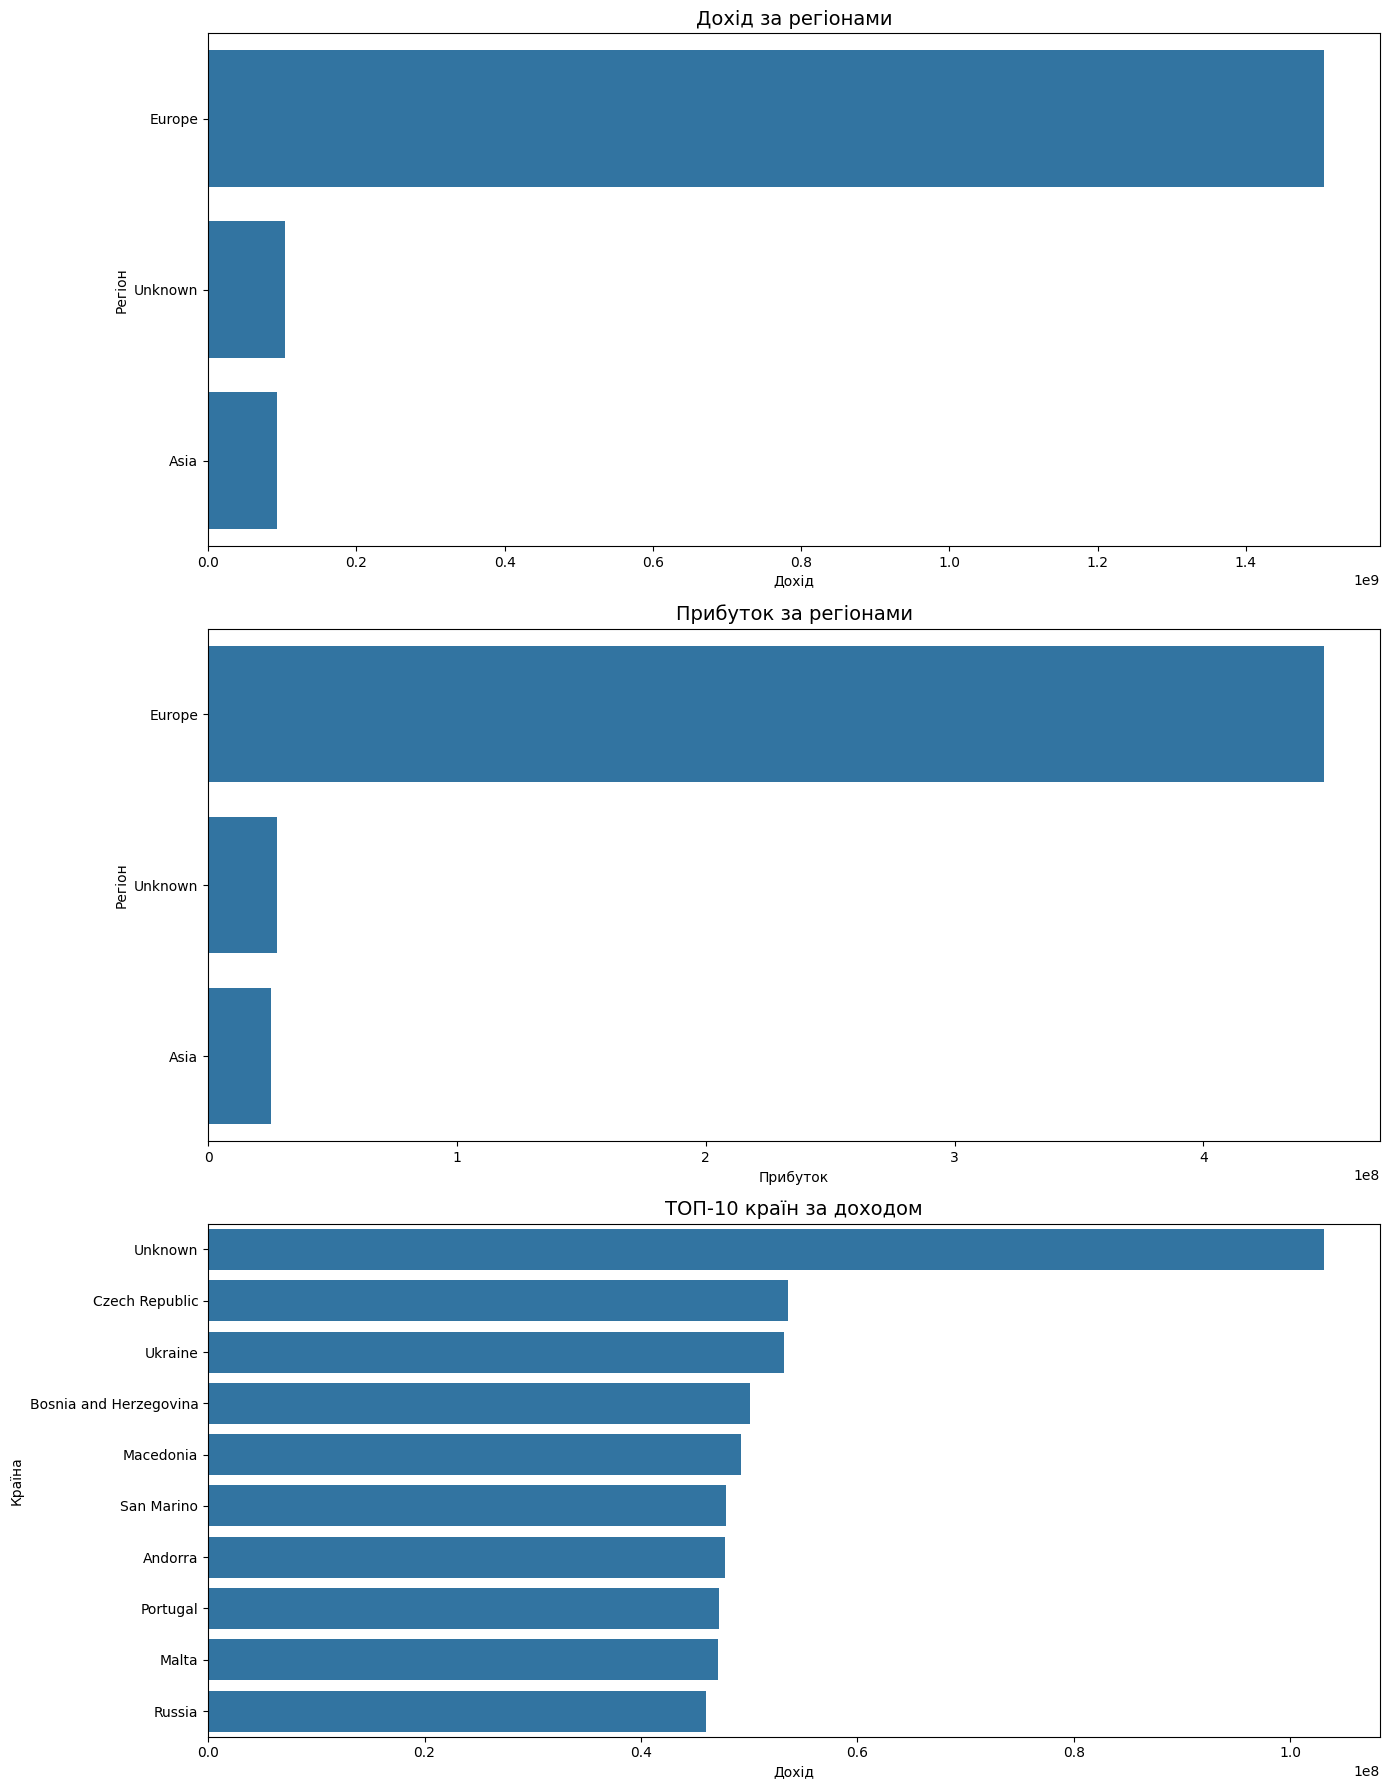

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Аналіз за регіонами
region_analysis = (
    df.groupby("region")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

region_analysis["profit_margin"] = (
    region_analysis["profit"] / region_analysis["revenue"] * 100
)

# Аналіз за країнами
country_analysis = (
    df.groupby(["country_code", "country"])
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

country_analysis["profit_margin"] = (
    country_analysis["profit"] / country_analysis["revenue"] * 100
)

# Виводимо таблиці
print("АНАЛІЗ ЗА РЕГІОНАМИ")
display(region_analysis.round(2))

print("ТОП-10 КРАЇН ЗА ДОХОДОМ")
display(country_analysis.head(10).round(2))

# Підготовка даних для графіків
region_revenue = region_analysis.reset_index()

country_revenue = (
    country_analysis
    .head(10)
    .reset_index()
)

# Створюємо 3 графіки
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Revenue за регіонами
sns.barplot(
    data=region_revenue,
    x="revenue",
    y="region",
    ax=axes[0]
)

axes[0].set_title("Дохід за регіонами", fontsize=14)
axes[0].set_xlabel("Дохід")
axes[0].set_ylabel("Регіон")

# Profit за регіонами
region_profit = (
    region_analysis
    .sort_values("profit", ascending=False)
    .reset_index()
)

sns.barplot(
    data=region_profit,
    x="profit",
    y="region",
    ax=axes[1]
)

axes[1].set_title("Прибуток за регіонами", fontsize=14)
axes[1].set_xlabel("Прибуток")
axes[1].set_ylabel("Регіон")

# ТОП-10 країн за revenue
sns.barplot(
    data=country_revenue,
    x="revenue",
    y="country",
    ax=axes[2]
)

axes[2].set_title("ТОП-10 країн за доходом", fontsize=14)
axes[2].set_xlabel("Дохід")
axes[2].set_ylabel("Країна")

plt.tight_layout()
plt.show()

### Висновок: географічний аналіз продажів

Географічний аналіз показав суттєву концентрацію продажів у Європі.

- **Europe** є безумовним лідером: регіон має **1 164 замовлення**, дохід близько **$1,506 млрд** та прибуток близько **$448,6 млн**.
- На Європу припадає переважна частина загального доходу та прибутку компанії. Її маржинальність становить **29,79%**.
- **Asia** має 82 замовлення, дохід близько **$93,3 млн** та прибуток близько **$25,2 млн**. Маржинальність — **26,95%**.
- Для **82 замовлень** країна була невідома. Ці продажі збережено в аналізі під категорією `Unknown`, щоб не втрачати дані. Їхній дохід становить близько **$103,1 млн**, а прибуток — **$27,7 млн**.
- Серед відомих країн найбільший дохід мають **Czech Republic ($53,5 млн)**, **Ukraine ($53,3 млн)** та **Bosnia and Herzegovina ($50,1 млн)**.
- **Andorra** демонструє найвищу маржинальність серед наведених країн — **32,27%**, а **Malta** — **30,99%**.
- Отже, основним ринком компанії є **Європа**, тоді як Азія має значно менший обсяг продажів. Водночас окремі країни демонструють високу прибутковість навіть за відносно невеликого доходу.

,orders,units_sold,revenue,cost,profit,profit_margin
sales_channel,,,,,,
Offline,665,3320363.0,8.717606e+08,6.182941e+08,2.534665e+08,29.08
Online,663,3256161.0,8.303688e+08,5.824008e+08,2.479679e+08,29.86


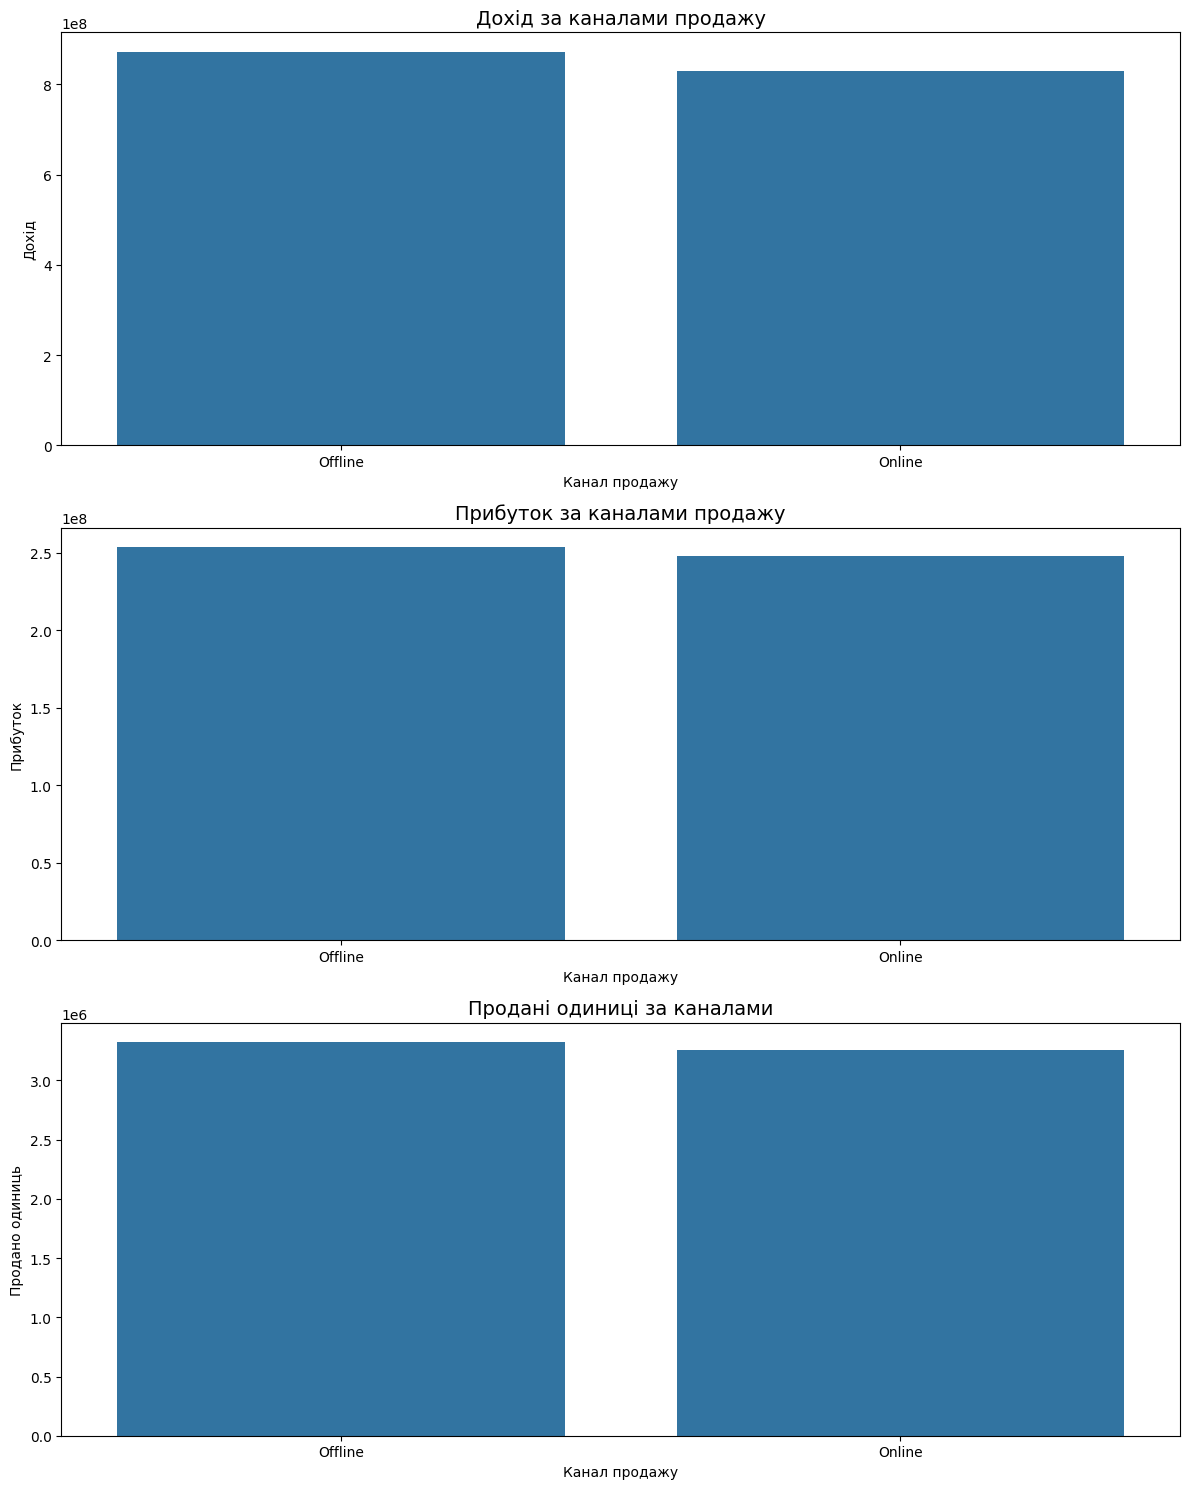

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Аналіз каналів продажу
channel_analysis = (
    df.groupby("sales_channel")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
)

channel_analysis["profit_margin"] = (
    channel_analysis["profit"] / channel_analysis["revenue"] * 100
)

# Виводимо таблицю
display(channel_analysis.round(2))

# Підготовка даних
channel_data = channel_analysis.reset_index()

# Графіки
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Revenue
sns.barplot(
    data=channel_data,
    x="sales_channel",
    y="revenue",
    ax=axes[0]
)
axes[0].set_title("Дохід за каналами продажу", fontsize=14)
axes[0].set_xlabel("Канал продажу")
axes[0].set_ylabel("Дохід")

# Profit
sns.barplot(
    data=channel_data,
    x="sales_channel",
    y="profit",
    ax=axes[1]
)
axes[1].set_title("Прибуток за каналами продажу", fontsize=14)
axes[1].set_xlabel("Канал продажу")
axes[1].set_ylabel("Прибуток")

# Units sold
sns.barplot(
    data=channel_data,
    x="sales_channel",
    y="units_sold",
    ax=axes[2]
)
axes[2].set_title("Продані одиниці за каналами", fontsize=14)
axes[2].set_xlabel("Канал продажу")
axes[2].set_ylabel("Продано одиниць")

plt.tight_layout()
plt.show()

### Висновок: аналіз каналів продажу

Аналіз Online та Offline каналів показав, що їхні результати є досить близькими.

- **Offline** має трохи більше замовлень — **665 проти 663** в Online.
- За кількістю проданих одиниць Offline також незначно випереджає Online: **3,32 млн проти 3,26 млн одиниць**.
- Дохід Offline становить близько **$871,8 млн**, тоді як Online — близько **$830,4 млн**.
- За абсолютним прибутком Offline також має невелику перевагу: **$253,5 млн проти $248,0 млн**.
- Водночас **Online має вищу маржинальність — 29,86%**, порівняно з **29,08%** для Offline.
- Отже, Offline генерує дещо більші абсолютні обсяги доходу та прибутку, але Online є **трохи ефективнішим за прибутковістю відносно доходу**.
- Загалом різниця між каналами невелика, тому жоден канал не демонструє кардинальної переваги.

СТАТИСТИКА ЧАСУ ДОСТАВКИ


,shipping_days
count,1328.00
mean,24.79
std,14.59
min,0.00
25%,12.00
50%,25.00
75%,37.00
max,50.00


ЧАС ДОСТАВКИ ЗА КАТЕГОРІЯМИ


,count,mean,median,min,max
product_category,,,,,
Cereal,103,27.18,29.0,0,50
Office Supplies,123,26.71,27.0,1,50
Baby Food,112,26.34,28.5,0,50
Cosmetics,114,25.91,28.0,0,50
Meat,110,25.91,25.0,0,50
Snacks,103,25.54,25.0,0,49
Fruits,112,24.42,23.0,1,50
Beverages,121,24.12,23.0,0,50
Household,97,23.94,24.0,0,50


ЧАС ДОСТАВКИ ЗА РЕГІОНАМИ


,count,mean,median,min,max
region,,,,,
Asia,82,26.09,25.5,1,50
Europe,1164,24.79,25.0,0,50
Unknown,82,23.44,23.5,0,50


ЧАС ДОСТАВКИ ЗА КРАЇНАМИ


,count,mean,median,min,max
country,,,,,
Hungary,25,32.64,36.0,2,50
Georgia,23,29.70,32.0,7,47
Austria,28,28.50,29.0,3,50
Slovakia,30,28.47,32.0,3,50
Luxembourg,28,27.75,30.5,0,48
Lithuania,25,27.56,30.0,5,49
Poland,28,27.46,27.0,6,50
Russia,32,27.38,34.0,0,50
Monaco,13,26.85,33.0,5,48


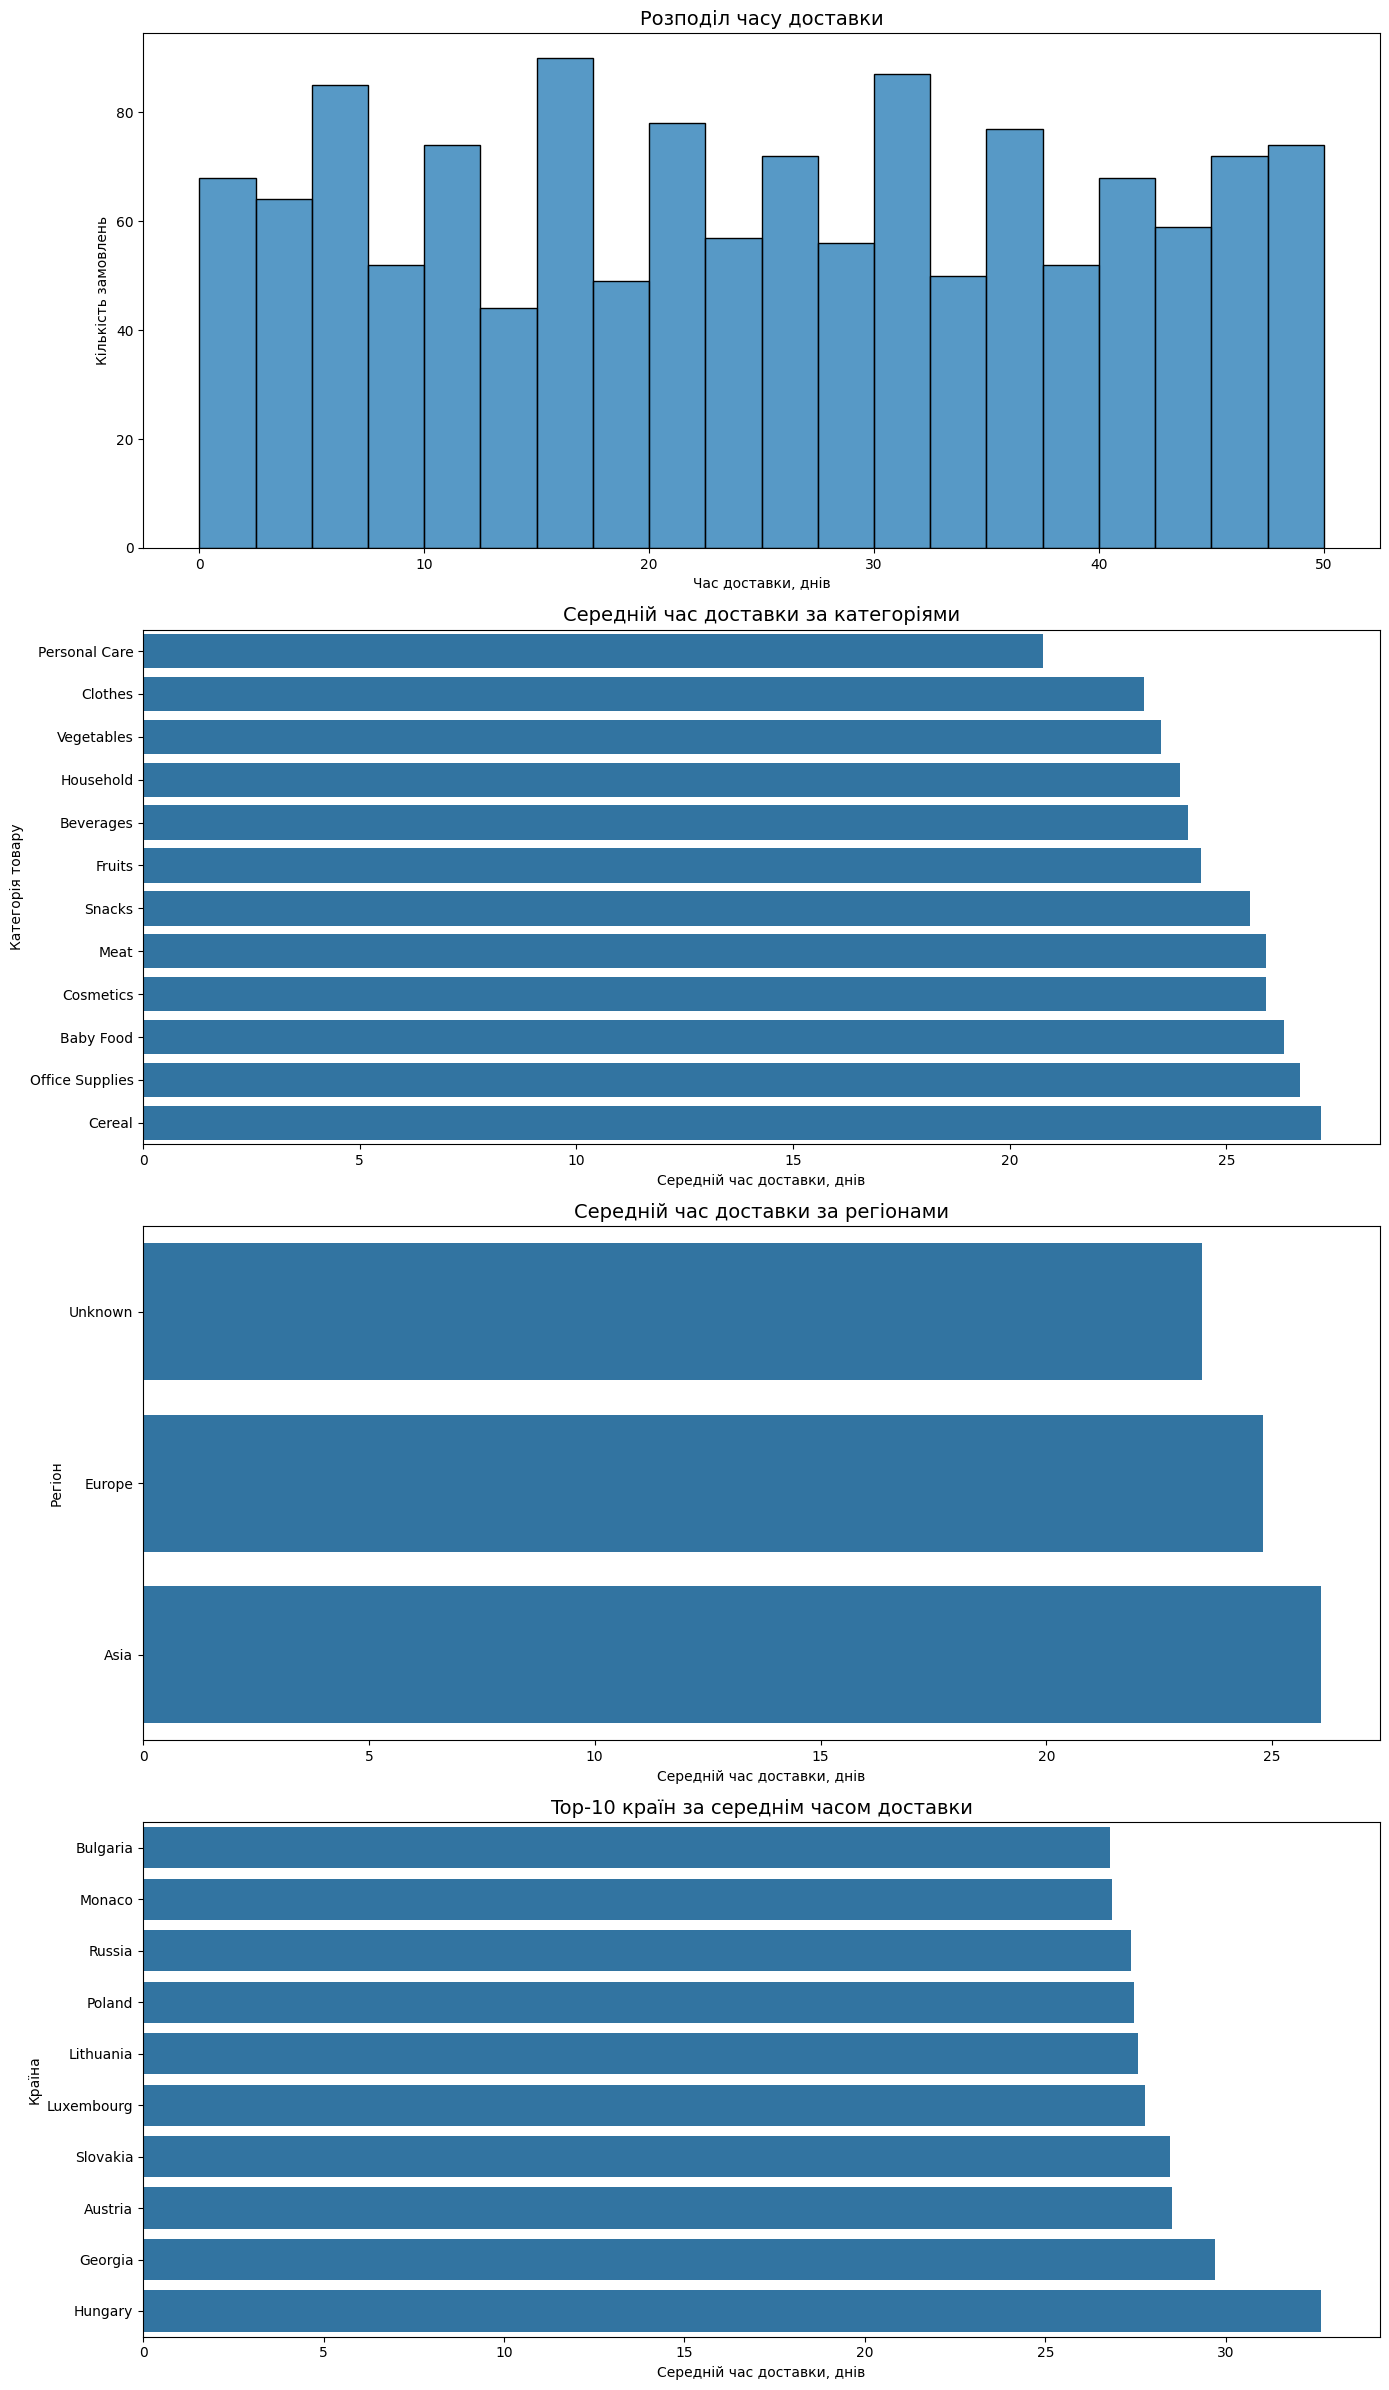

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Загальна статистика часу доставки
shipping_stats = df["shipping_days"].describe()

print("СТАТИСТИКА ЧАСУ ДОСТАВКИ")
display(shipping_stats.round(2))


# Середній час доставки за категоріями
shipping_by_category = (
    df.groupby("product_category")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("ЧАС ДОСТАВКИ ЗА КАТЕГОРІЯМИ")
display(shipping_by_category.round(2))


# Середній час доставки за регіонами
shipping_by_region = (
    df.groupby("region")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("ЧАС ДОСТАВКИ ЗА РЕГІОНАМИ")
display(shipping_by_region.round(2))


# Середній час доставки за країнами
shipping_by_country = (
    df.groupby("country")["shipping_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("ЧАС ДОСТАВКИ ЗА КРАЇНАМИ")
display(shipping_by_country.round(2))


# ============================================================
# ГРАФІКИ
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 24))


# ------------------------------------------------------------
# 1. Розподіл shipping days
# ------------------------------------------------------------

sns.histplot(
    data=df,
    x="shipping_days",
    bins=20,
    ax=axes[0]
)

axes[0].set_title(
    "Розподіл часу доставки",
    fontsize=14
)

axes[0].set_xlabel(
    "Час доставки, днів"
)

axes[0].set_ylabel(
    "Кількість замовлень"
)


# ------------------------------------------------------------
# 2. Середній час доставки за категоріями
# ------------------------------------------------------------

category_shipping_plot = (
    shipping_by_category
    .reset_index()
    .sort_values("mean", ascending=True)
)

sns.barplot(
    data=category_shipping_plot,
    x="mean",
    y="product_category",
    ax=axes[1]
)

axes[1].set_title(
    "Середній час доставки за категоріями",
    fontsize=14
)

axes[1].set_xlabel(
    "Середній час доставки, днів"
)

axes[1].set_ylabel(
    "Категорія товару"
)


# ------------------------------------------------------------
# 3. Середній час доставки за регіонами
# ------------------------------------------------------------

region_shipping_plot = (
    shipping_by_region
    .reset_index()
    .sort_values("mean", ascending=True)
)

sns.barplot(
    data=region_shipping_plot,
    x="mean",
    y="region",
    ax=axes[2]
)

axes[2].set_title(
    "Середній час доставки за регіонами",
    fontsize=14
)

axes[2].set_xlabel(
    "Середній час доставки, днів"
)

axes[2].set_ylabel(
    "Регіон"
)


# ------------------------------------------------------------
# 4. TOP-10 країн за середнім часом доставки
# ------------------------------------------------------------

country_shipping_plot = (
    shipping_by_country
    .reset_index()
    .sort_values("mean", ascending=False)
    .head(10)
    .sort_values("mean", ascending=True)
)

sns.barplot(
    data=country_shipping_plot,
    x="mean",
    y="country",
    ax=axes[3]
)

axes[3].set_title(
    "Top-10 країн за середнім часом доставки",
    fontsize=14
)

axes[3].set_xlabel(
    "Середній час доставки, днів"
)

axes[3].set_ylabel(
    "Країна"
)


plt.tight_layout()
plt.show()

### Висновок: аналіз часу доставки

Середній час доставки становить **24,79 дня**, медіанне значення — **25 днів**. Значення часу доставки знаходяться в межах від **0 до 50 днів**.

- 25% замовлень доставляються не довше ніж за **12 днів**.
- Для 50% замовлень час доставки не перевищує **25 днів**.
- 75% замовлень доставляються не довше ніж за **37 днів**.
- Найдовший зафіксований час доставки становить **50 днів**.

За категоріями найбільший середній час доставки мають **Cereal — 27,18 дня**, **Office Supplies — 26,71 дня** та **Baby Food — 26,34 дня**.

Найшвидше в середньому доставляються **Personal Care — 20,76 дня**, **Clothes — 23,10 дня** та **Vegetables — 23,49 дня**.

За регіонами найдовший середній час доставки спостерігається в **Asia — 26,09 дня**, тоді як у **Europe — 24,79 дня**. Для замовлень із невідомим регіоном середній час доставки становить **23,44 дня**.

Додатково час доставки було проаналізовано **в розрізі країн**. Для деталізації регіонального аналізу визначено **Top-10 країн за середнім часом доставки**. Це дозволяє виявити окремі країни, у яких логістика є потенційно повільнішою, навіть якщо загальний показник їхнього регіону не є критичним.

Таким чином, час доставки відрізняється залежно від **категорії товару, регіону та країни**. Для подальшої оптимізації логістики доцільно окремо досліджувати країни з найбільшим середнім часом доставки та визначати причини таких відмінностей.

Кореляція між часом доставки та прибутком: 0.060
ПРИБУТОК ЗА ІНТЕРВАЛАМИ ДОСТАВКИ


,orders,avg_profit,total_profit,avg_revenue
shipping_group,,,,
0–10 днів,285,345660.79,9.851332e+07,1095644.46
11–20 днів,267,364997.53,9.745434e+07,1293046.69
21–30 днів,255,371288.14,9.467848e+07,1261051.90
31–40 днів,275,414791.51,1.140677e+08,1415067.86
41–50 днів,246,393173.39,9.672065e+07,1357379.57


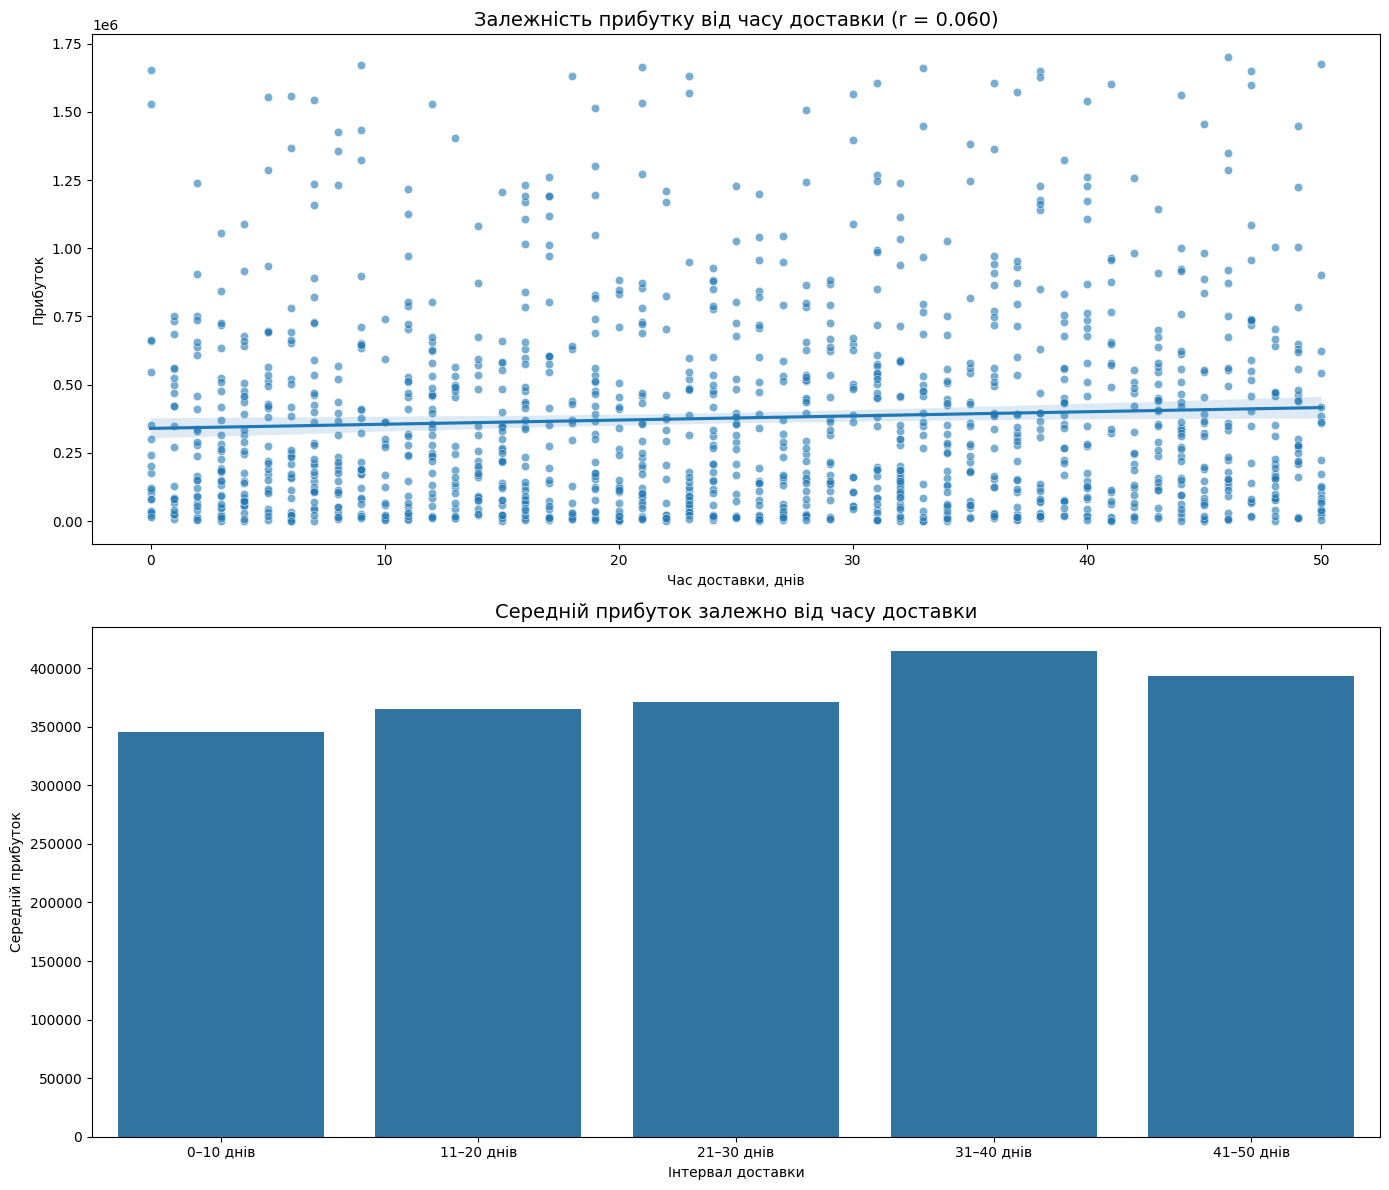

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Кореляція між часом доставки та прибутком
shipping_profit_corr = df["shipping_days"].corr(df["profit"])

print(f"Кореляція між часом доставки та прибутком: {shipping_profit_corr:.3f}")

# Створюємо інтервали часу доставки
df["shipping_group"] = pd.cut(
    df["shipping_days"],
    bins=[-1, 10, 20, 30, 40, 50],
    labels=[
        "0–10 днів",
        "11–20 днів",
        "21–30 днів",
        "31–40 днів",
        "41–50 днів"
    ]
)

shipping_profit = (
    df.groupby("shipping_group", observed=True)
    .agg(
        orders=("order_id", "nunique"),
        avg_profit=("profit", "mean"),
        total_profit=("profit", "sum"),
        avg_revenue=("revenue", "mean")
    )
)

print("ПРИБУТОК ЗА ІНТЕРВАЛАМИ ДОСТАВКИ")
display(shipping_profit.round(2))

# Графіки
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Scatter plot
sns.scatterplot(
    data=df,
    x="shipping_days",
    y="profit",
    alpha=0.6,
    ax=axes[0]
)

sns.regplot(
    data=df,
    x="shipping_days",
    y="profit",
    scatter=False,
    ax=axes[0]
)

axes[0].set_title(
    f"Залежність прибутку від часу доставки (r = {shipping_profit_corr:.3f})",
    fontsize=14
)
axes[0].set_xlabel("Час доставки, днів")
axes[0].set_ylabel("Прибуток")

# Average profit by shipping group
shipping_profit_plot = shipping_profit.reset_index()

sns.barplot(
    data=shipping_profit_plot,
    x="shipping_group",
    y="avg_profit",
    ax=axes[1]
)

axes[1].set_title("Середній прибуток залежно від часу доставки", fontsize=14)
axes[1].set_xlabel("Інтервал доставки")
axes[1].set_ylabel("Середній прибуток")

plt.tight_layout()
plt.show()

### Висновок: залежність прибутку від часу доставки

Кореляція між часом доставки та прибутком становить **0,060**, що свідчить про дуже слабкий позитивний лінійний зв'язок.

Середній прибуток за інтервалами доставки коливається від **$345,660.79** для замовлень із доставкою за 0–10 днів до **$414,791.51** для замовлень із доставкою за 31–40 днів.

При цьому чіткої тенденції до зростання або зменшення прибутку зі збільшенням часу доставки не спостерігається. Наприклад, після максимального середнього прибутку в інтервалі 31–40 днів він знижується в інтервалі 41–50 днів.

Отже, **час доставки практично не пов'язаний із прибутком у цьому наборі даних**. Виявлена кореляція є занадто слабкою, щоб вважати час доставки суттєвим фактором формування прибутку. Водночас кореляція не доводить причинно-наслідкового зв'язку.

ДИНАМІКА ПРОДАЖІВ ЗА РОКАМИ


,orders,units_sold,revenue,profit
year,,,,
2010,166,843713.0,2.093822e+08,61422459.90
2011,175,906147.0,2.319376e+08,69044659.73
2012,202,1055249.0,2.854859e+08,87884066.44
2013,158,770550.0,1.829624e+08,53387995.18
2014,186,904727.0,2.362858e+08,71189625.60
2015,160,758689.0,2.279541e+08,61734039.82
2016,175,823955.0,1.915210e+08,57771920.85
2017,106,513494.0,1.366005e+08,38999691.48


ДИНАМІКА ПРОДАЖІВ ЗА МІСЯЦЯМИ


,year,month,orders,units_sold,revenue,profit
0,2010,1,20,110109.0,21115354.48,8567689.01
1,2010,2,12,68209.0,19853023.20,4306485.07
2,2010,3,11,49618.0,8474747.19,3093055.70
3,2010,4,6,34618.0,10058016.05,2320389.85
4,2010,5,18,95604.0,20304725.59,6655673.86
5,2010,6,15,74569.0,25063003.94,6672461.19
6,2010,7,11,64070.0,12710132.81,3871434.93
7,2010,8,12,60065.0,12358689.84,3999209.52
8,2010,9,19,76165.0,18848990.58,6483546.70
9,2010,10,16,87194.0,23899826.50,6196349.91


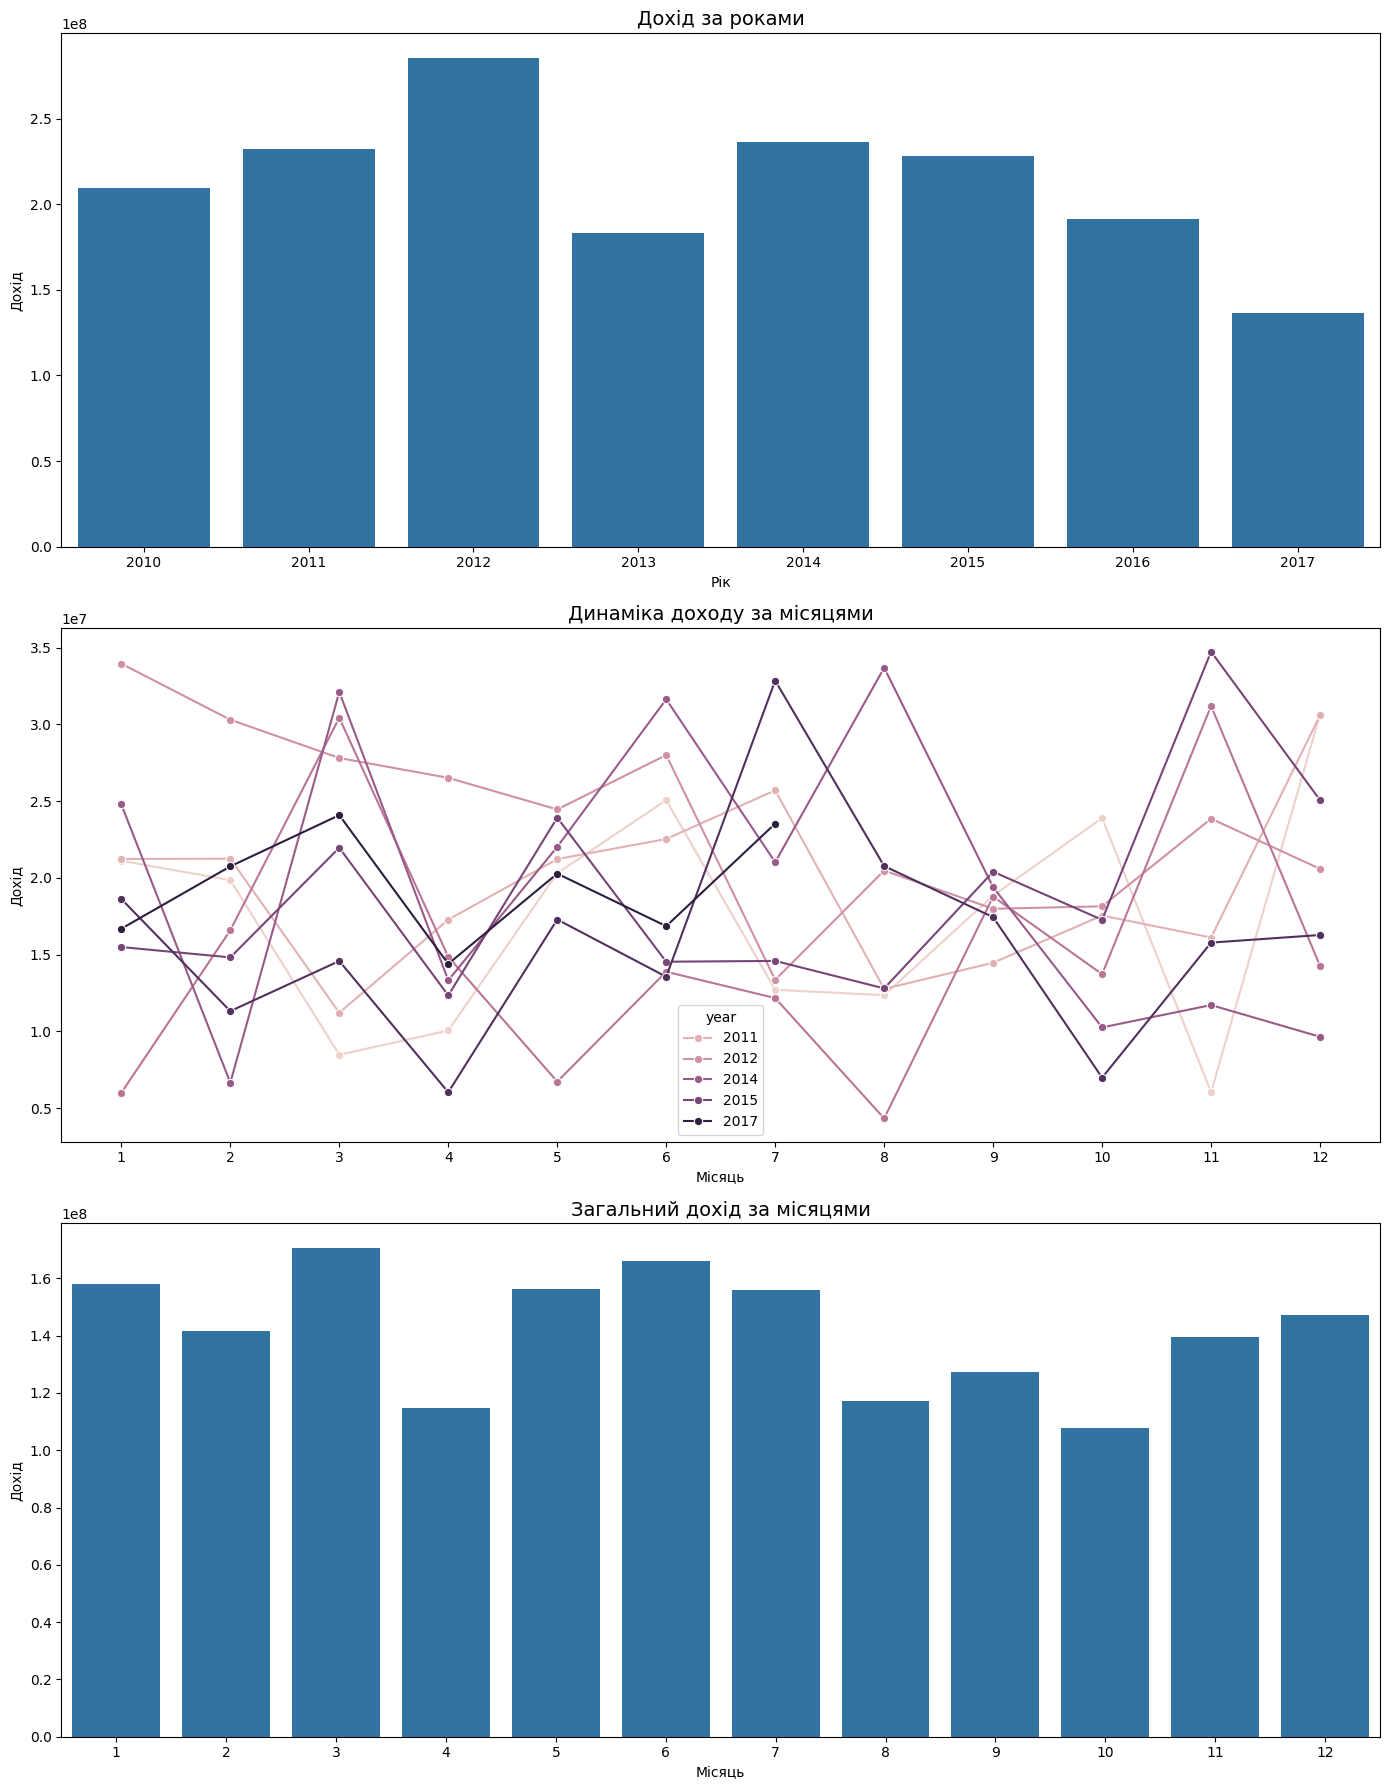

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Динаміка за роками
# ==========================================

year_analysis = (
    df.groupby("year")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
)

print("ДИНАМІКА ПРОДАЖІВ ЗА РОКАМИ")
display(year_analysis.round(2))


# ==========================================
# 2. Динаміка за місяцями
# ==========================================

month_analysis = (
    df.groupby(["year", "month"])
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

print("ДИНАМІКА ПРОДАЖІВ ЗА МІСЯЦЯМИ")
display(month_analysis.round(2))


# ==========================================
# 3. Середній revenue за місяцями
# ==========================================

monthly_revenue = (
    df.groupby("month")["revenue"]
    .sum()
    .reset_index()
)

# ==========================================
# Графіки
# ==========================================

fig, axes = plt.subplots(3, 1, figsize=(14, 18))


# Revenue за роками
sns.barplot(
    data=year_analysis.reset_index(),
    x="year",
    y="revenue",
    ax=axes[0]
)

axes[0].set_title("Дохід за роками", fontsize=14)
axes[0].set_xlabel("Рік")
axes[0].set_ylabel("Дохід")


# Revenue за місяцями та роками
sns.lineplot(
    data=month_analysis,
    x="month",
    y="revenue",
    hue="year",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Динаміка доходу за місяцями", fontsize=14)
axes[1].set_xlabel("Місяць")
axes[1].set_ylabel("Дохід")
axes[1].set_xticks(range(1, 13))


# Загальна сезонність
sns.barplot(
    data=monthly_revenue,
    x="month",
    y="revenue",
    ax=axes[2]
)

axes[2].set_title("Загальний дохід за місяцями", fontsize=14)
axes[2].set_xlabel("Місяць")
axes[2].set_ylabel("Дохід")

plt.tight_layout()
plt.show()

### Висновок: динаміка продажів у часі

Аналіз динаміки продажів за 2010–2017 роки показав нестабільну тенденцію з піком у середині досліджуваного періоду.

- У **2010 році** дохід становив близько **$209,4 млн**, а прибуток — **$61,4 млн**.
- Найвищі показники за весь період спостерігаються у **2012 році**: дохід становив близько **$285,5 млн**, а прибуток — **$87,9 млн**.
- У **2013 році** відбулося помітне зниження доходу до **$183,0 млн** та прибутку до **$53,4 млн**.
- У **2014 році** продажі частково відновилися: дохід зріс до **$236,3 млн**, а прибуток — до **$71,2 млн**.
- Після 2014 року спостерігається загальна тенденція до зниження. У **2017 році** дохід становив лише **$136,6 млн**, а прибуток — **$39,0 млн**.
- Таким чином, **2012 рік є найуспішнішим**, а **2017 рік — найслабшим** за доходом і прибутком.

Місячна динаміка демонструє значні коливання продажів усередині кожного року. Наприклад, високі значення доходу спостерігалися у грудні 2010 року, грудні 2011 року, січні 2012 року, березні та серпні 2014 року, а також листопаді 2015 року.

Отже, **вираженої стабільної сезонності за одним конкретним місяцем не спостерігається**: пікові місяці змінюються залежно від року. Продажі характеризуються значними місячними коливаннями, а в довгостроковій перспективі після піку 2012 року спостерігається загальне зниження.

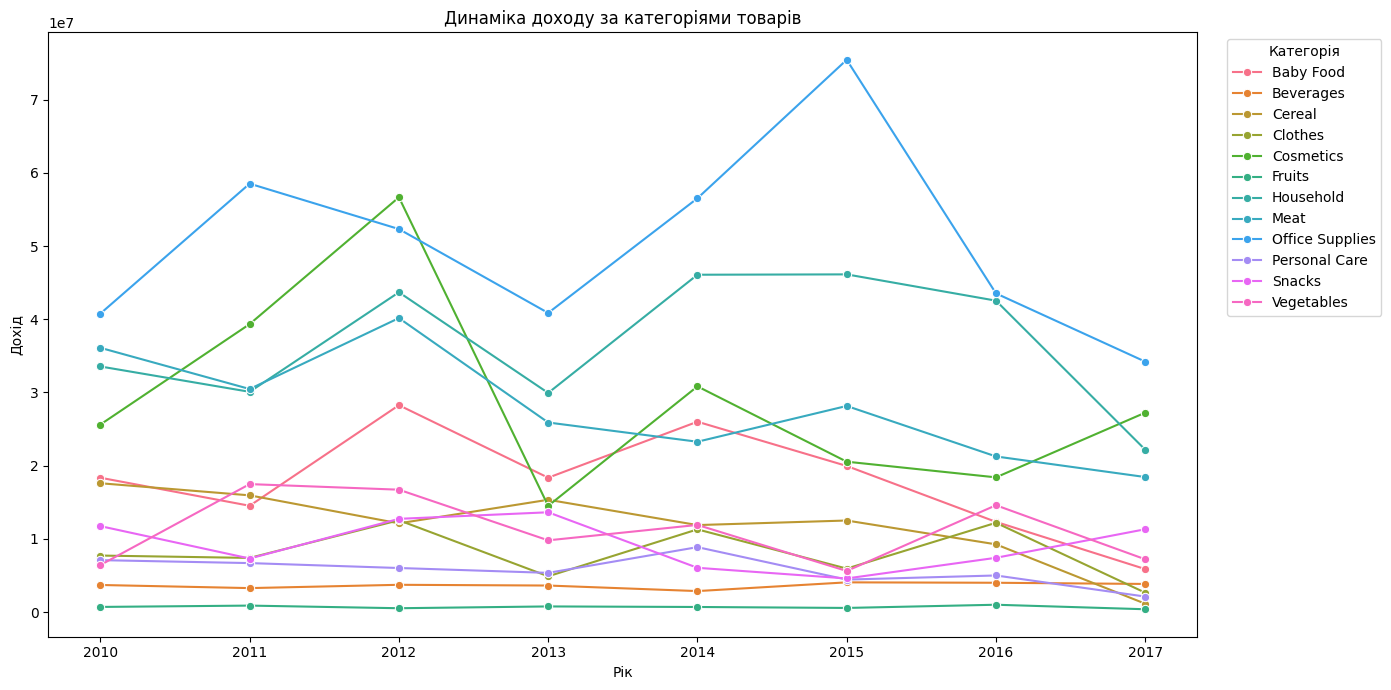

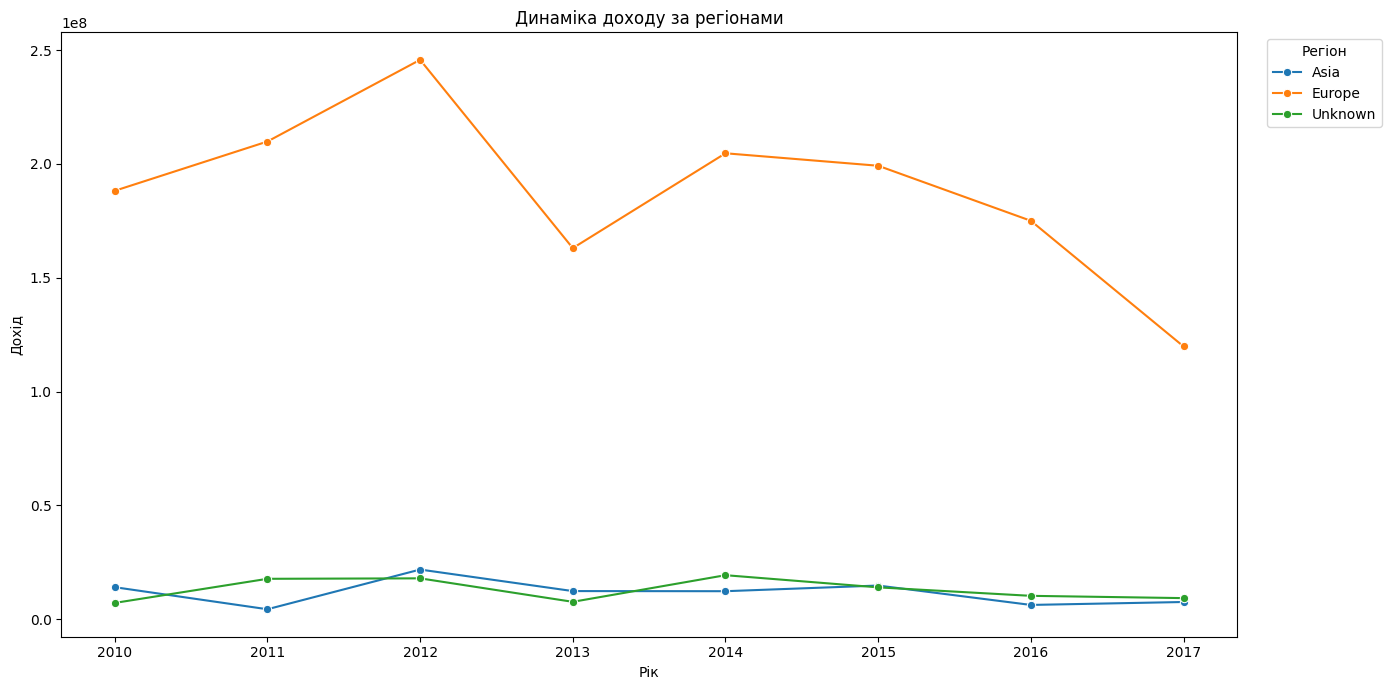

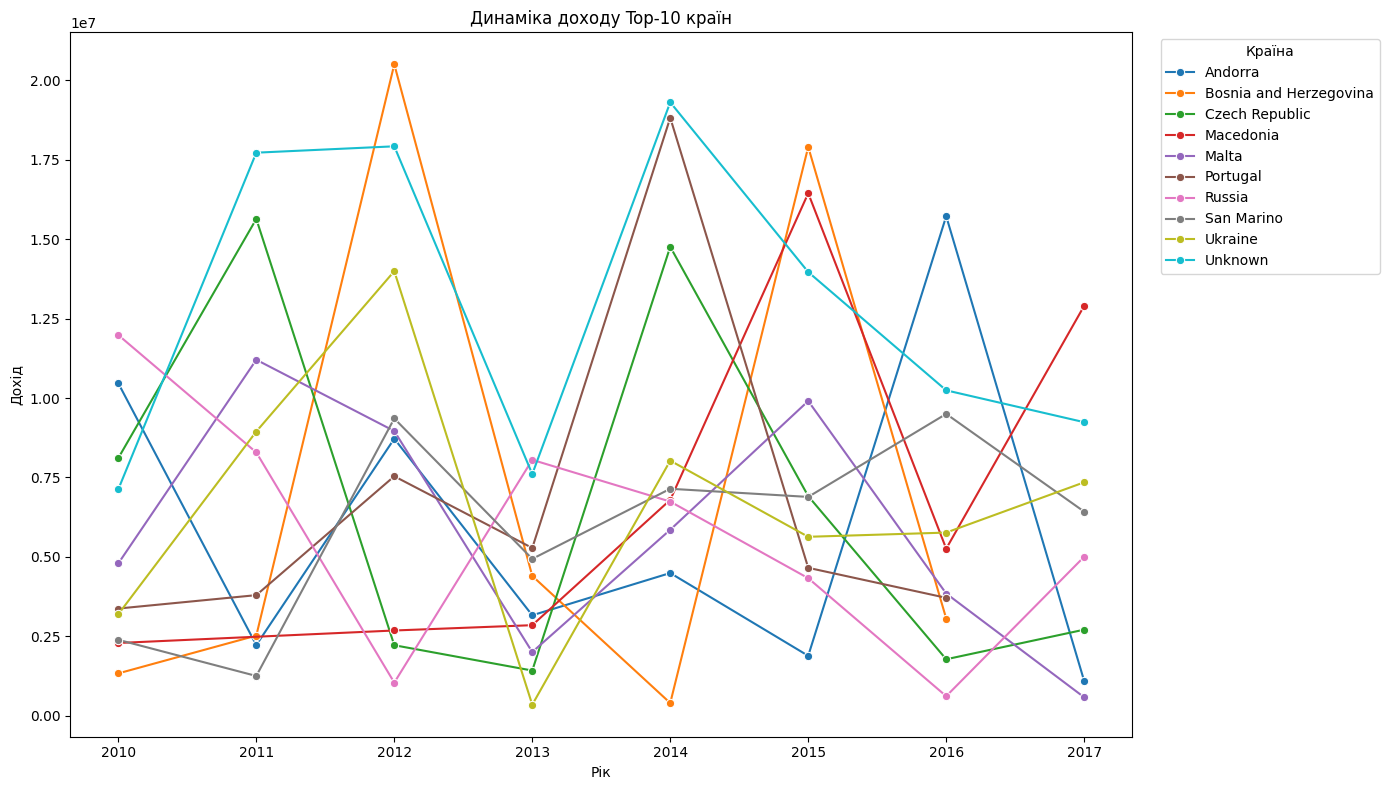

In [ ]:
# ============================================================
# ДИНАМІКА ДОХОДУ ЗА КАТЕГОРІЯМИ, РЕГІОНАМИ ТА КРАЇНАМИ
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. Дохід за категоріями та роками
# ------------------------------------------------------------

category_year = (
    df.groupby(["year", "product_category"])["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=category_year,
    x="year",
    y="revenue",
    hue="product_category",
    marker="o"
)

plt.title("Динаміка доходу за категоріями товарів")
plt.xlabel("Рік")
plt.ylabel("Дохід")

plt.legend(
    title="Категорія",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Дохід за регіонами та роками
# ------------------------------------------------------------

region_year = (
    df.groupby(["year", "region"])["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=region_year,
    x="year",
    y="revenue",
    hue="region",
    marker="o"
)

plt.title("Динаміка доходу за регіонами")
plt.xlabel("Рік")
plt.ylabel("Дохід")

plt.legend(
    title="Регіон",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Дохід за країнами та роками
# ------------------------------------------------------------

country_year = (
    df.groupby(["year", "country"])["revenue"]
    .sum()
    .reset_index()
)

# Визначаємо Top-10 країн за загальним доходом
top_countries = (
    country_year
    .groupby("country")["revenue"]
    .sum()
    .nlargest(10)
    .index
)

country_year_top10 = country_year[
    country_year["country"].isin(top_countries)
]

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=country_year_top10,
    x="year",
    y="revenue",
    hue="country",
    marker="o"
)

plt.title("Динаміка доходу Top-10 країн")
plt.xlabel("Рік")
plt.ylabel("Дохід")

plt.legend(
    title="Країна",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Висновок: динаміка доходу за категоріями, регіонами та країнами

Динаміка доходу була проаналізована в розрізі **товарних категорій, регіонів та країн** протягом 2010–2017 років.

За категоріями спостерігаються значні відмінності в динаміці:

- **Office Supplies** є стабільним лідером за доходом протягом більшості років. Особливо високі показники спостерігалися у **2015 році**, коли дохід перевищив **$75 млн**.
- **Cosmetics** демонструє найбільш помітні коливання: дохід суттєво зріс у 2012 році, досягнувши близько **$57 млн**, після чого знизився у 2013 році та знову зростав у наступні роки.
- **Household** також має високі показники доходу. Найбільший рівень спостерігається у **2014–2015 роках — близько $46 млн**.
- **Meat** поступово знижує дохід після високих значень у 2012 році, хоча у 2015 році спостерігається тимчасове зростання.
- **Baby Food** має помітні коливання залежно від року.
- У 2017 році доходи більшості категорій знизилися, що відповідає загальному зниженню продажів компанії.

У регіональному розрізі **Europe залишається основним джерелом доходу протягом досліджуваного періоду**. Саме зміни продажів у Європі значною мірою визначають загальну динаміку компанії, оскільки цей регіон має значно більший обсяг продажів порівняно з Asia.

Для деталізації регіонального аналізу було досліджено **Top-10 країн за сумарним доходом**. Динаміка окремих країн відрізняється: результати найбільших географічних ринків змінюються залежно від року, тому їх доцільно контролювати окремо, а не оцінювати лише на рівні регіону.

Отже, аналіз показує, що зміни загального доходу компанії формуються під впливом одночасно **товарної структури та географії продажів**. Для детальнішого планування важливо контролювати динаміку окремих категорій, регіонів та ключових країн.

ПРОДАЖІ ЗА ДНЯМИ ТИЖНЯ


,orders,units_sold,revenue,profit,profit_margin
day_of_week,,,,,
Monday,201,1027424.0,2.754685e+08,75790330.12,27.51
Tuesday,182,863568.0,2.135239e+08,65637400.07,30.74
Wednesday,194,900973.0,2.612157e+08,72323843.38,27.69
Thursday,167,850351.0,2.149222e+08,64325663.17,29.93
Friday,176,866387.0,2.638070e+08,79234529.04,30.04
Saturday,201,1015852.0,2.336411e+08,71435860.49,30.58
Sunday,207,1051969.0,2.395510e+08,72686832.73,30.34


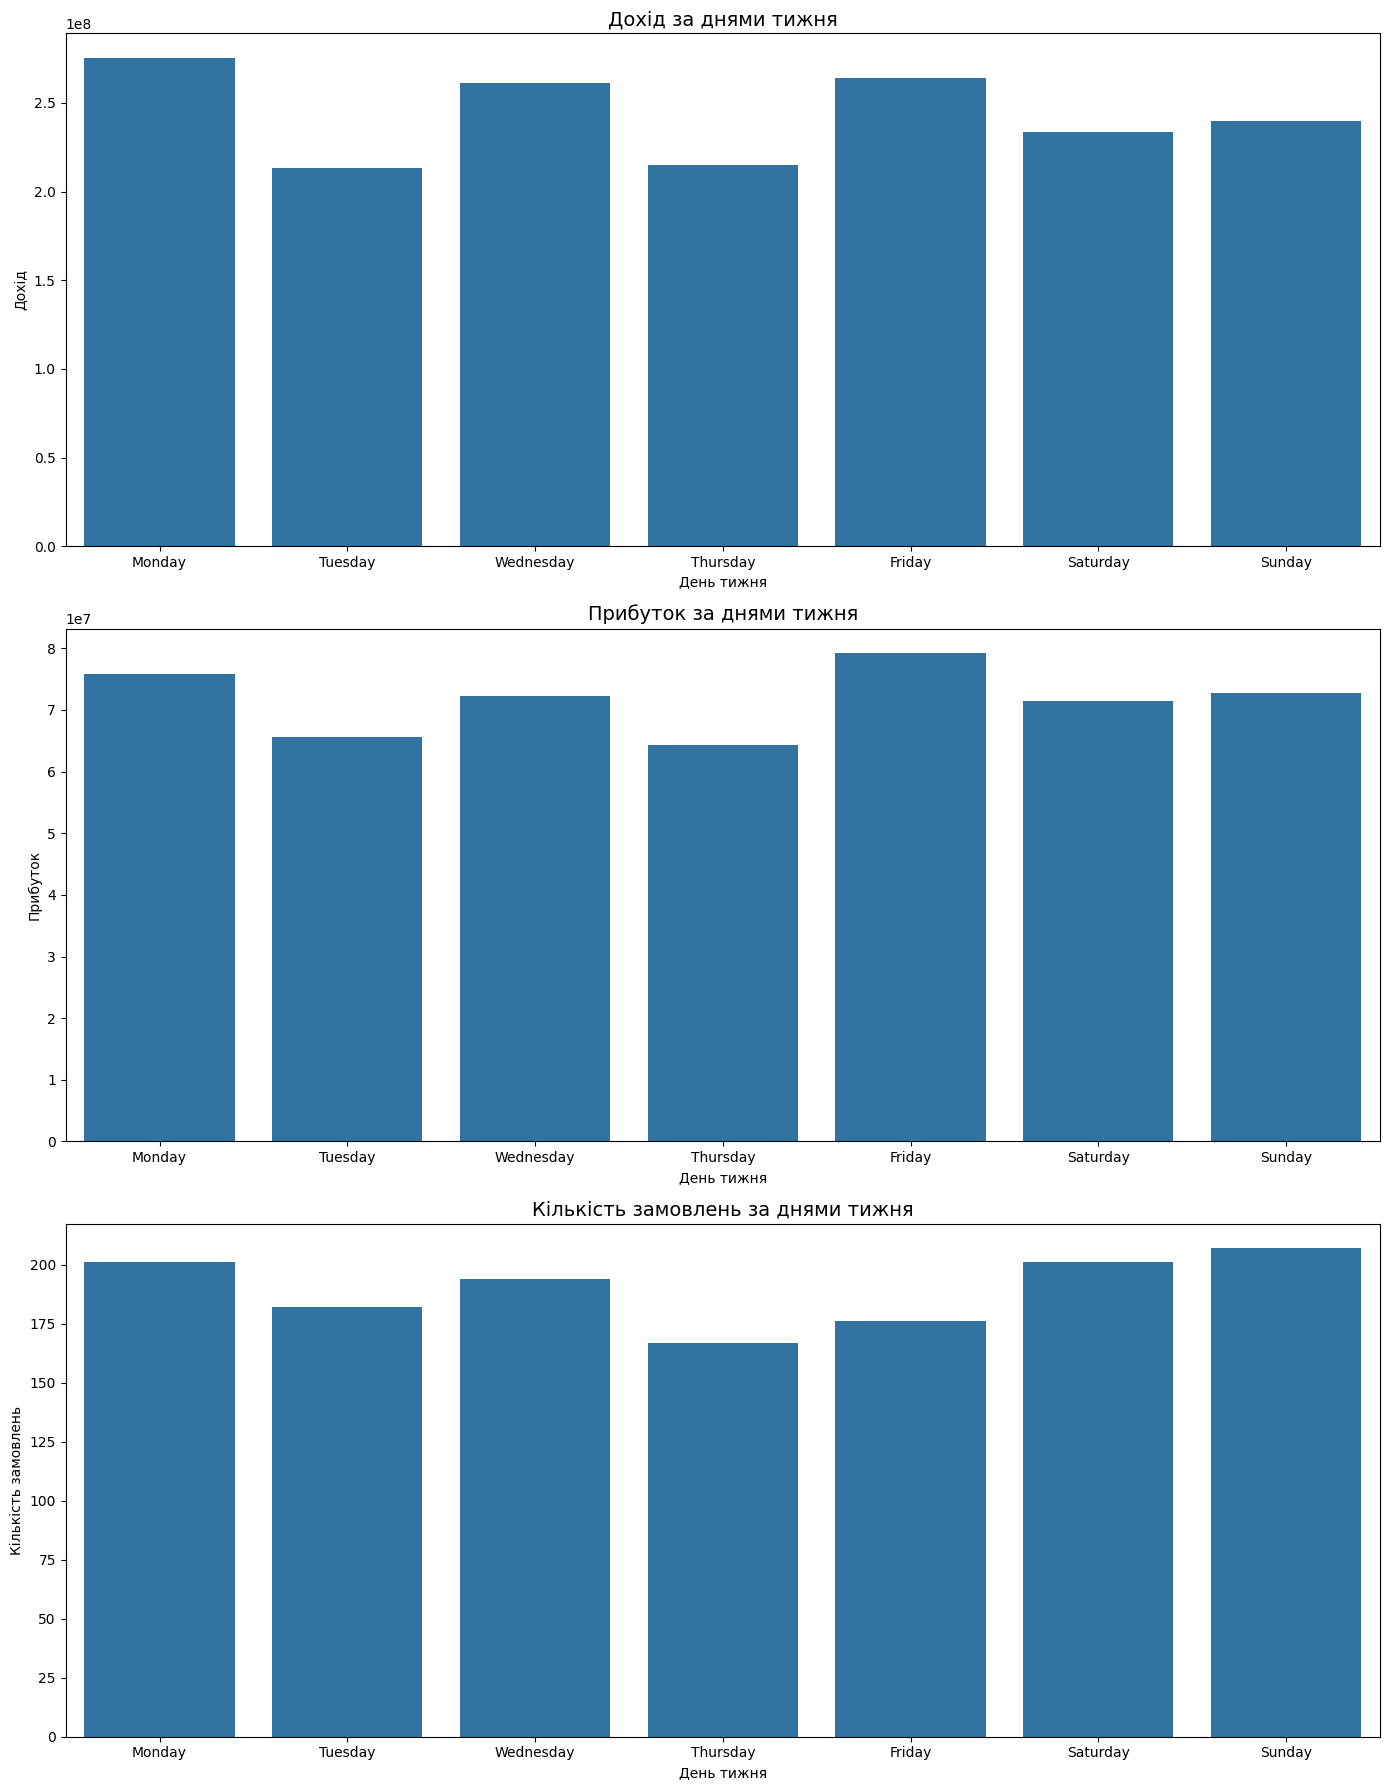

In [ ]:
# Аналіз продажів за днями тижня

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_analysis = (
    df.groupby("day_of_week")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reindex(weekday_order)
)

weekday_analysis["profit_margin"] = (
    weekday_analysis["profit"] /
    weekday_analysis["revenue"] * 100
)

print("ПРОДАЖІ ЗА ДНЯМИ ТИЖНЯ")
display(weekday_analysis.round(2))


# Графіки
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Revenue
sns.barplot(
    data=weekday_analysis.reset_index(),
    x="day_of_week",
    y="revenue",
    ax=axes[0]
)

axes[0].set_title("Дохід за днями тижня", fontsize=14)
axes[0].set_xlabel("День тижня")
axes[0].set_ylabel("Дохід")


# Profit
sns.barplot(
    data=weekday_analysis.reset_index(),
    x="day_of_week",
    y="profit",
    ax=axes[1]
)

axes[1].set_title("Прибуток за днями тижня", fontsize=14)
axes[1].set_xlabel("День тижня")
axes[1].set_ylabel("Прибуток")


# Orders
sns.barplot(
    data=weekday_analysis.reset_index(),
    x="day_of_week",
    y="orders",
    ax=axes[2]
)

axes[2].set_title("Кількість замовлень за днями тижня", fontsize=14)
axes[2].set_xlabel("День тижня")
axes[2].set_ylabel("Кількість замовлень")

plt.tight_layout()
plt.show()

### Висновок: продажі за днями тижня

Аналіз продажів за днями тижня показав, що найбільша кількість замовлень припадає на **неділю — 207 замовлень**, а найменша — на **четвер — 167 замовлень**.

- Найбільший дохід отримано в **понеділок — $275,5 млн**.
- Друге місце за доходом займає **середа — $261,2 млн**, а третє — **п'ятниця — $263,8 млн**.
- Найменший дохід спостерігається у **вівторок — $213,5 млн**.
- Найвищий абсолютний прибуток також припадає на **понеділок — $75,8 млн**.
- Найвища маржинальність спостерігається у **вівторок — 30,74%**, а найнижча — у **понеділок — 27,51%**.
- За кількістю проданих одиниць лідирує **неділя — 1,052 млн одиниць**, а найменше продано у **четвер — 850 тис. одиниць**.

Таким чином, **понеділок є найсильнішим днем за абсолютним доходом і прибутком**, тоді як **неділя має найбільшу кількість замовлень та проданих одиниць**. Водночас найвища прибутковість відносно доходу спостерігається у вівторок. Отже, кількість замовлень, дохід та маржинальність не завжди мають однакових лідерів.

# **FINAL BUSINESS INSIGHTS**

In [ ]:
# ============================================================
# FINAL SALES & PROFIT DASHBOARD
# ============================================================
# Interactive dashboard for the final project
# Google Colab
#
# Includes:
# - KPI
# - Year / Region / Country / Category / Channel filters
# - Sales dynamics
# - Product categories
# - Regions
# - Countries
# - Sales channels
# - Weekdays
# - Shipping analysis
# - Shipping time vs profit
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output


# ============================================================
# 2. PREPARE DATA
# ============================================================

dashboard_df = df.copy()

# Dates
dashboard_df["order_date"] = pd.to_datetime(
    dashboard_df["order_date"]
)

# Year
dashboard_df["year"] = (
    dashboard_df["order_date"].dt.year
)

# Day of week
dashboard_df["day_of_week"] = (
    dashboard_df["order_date"].dt.day_name()
)

# Missing geographic values
dashboard_df["country"] = (
    dashboard_df["country"]
    .fillna("Unknown")
)

dashboard_df["region"] = (
    dashboard_df["region"]
    .fillna("Unknown")
)

# Weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


# ============================================================
# 3. FILTER VALUES
# ============================================================

year_options = (
    ["All"] +
    sorted(
        dashboard_df["year"]
        .dropna()
        .unique()
        .tolist()
    )
)

region_options = (
    ["All"] +
    sorted(
        dashboard_df["region"]
        .dropna()
        .unique()
        .tolist()
    )
)

country_options = (
    ["All"] +
    sorted(
        dashboard_df["country"]
        .dropna()
        .unique()
        .tolist()
    )
)

category_options = (
    ["All"] +
    sorted(
        dashboard_df["product_category"]
        .dropna()
        .unique()
        .tolist()
    )
)

channel_options = (
    ["All"] +
    sorted(
        dashboard_df["sales_channel"]
        .dropna()
        .unique()
        .tolist()
    )
)


# ============================================================
# 4. FILTER WIDGETS
# ============================================================

year_filter = widgets.Dropdown(
    options=year_options,
    value="All",
    description="Year:",
    layout=widgets.Layout(
        width="180px"
    )
)

region_filter = widgets.Dropdown(
    options=region_options,
    value="All",
    description="Region:",
    layout=widgets.Layout(
        width="210px"
    )
)

country_filter = widgets.Dropdown(
    options=country_options,
    value="All",
    description="Country:",
    layout=widgets.Layout(
        width="260px"
    )
)

category_filter = widgets.Dropdown(
    options=category_options,
    value="All",
    description="Category:",
    layout=widgets.Layout(
        width="250px"
    )
)

channel_filter = widgets.Dropdown(
    options=channel_options,
    value="All",
    description="Channel:",
    layout=widgets.Layout(
        width="210px"
    )
)


# ============================================================
# 5. DASHBOARD HEADER
# ============================================================

display(
    HTML(
        """
        <div style="
            text-align:center;
            margin:10px 0 20px 0;
        ">

            <h1 style="
                font-size:32px;
                margin-bottom:5px;
            ">
                SALES & PROFIT DASHBOARD
            </h1>

            <p style="
                color:#777;
                font-size:15px;
                margin-top:0;
            ">
                Interactive analysis of sales, profit,
                products, geography and logistics
            </p>

        </div>
        """
    )
)


# ============================================================
# 6. FILTER PANEL
# ============================================================

display(
    widgets.HBox(
        [
            year_filter,
            region_filter,
            country_filter,
            category_filter,
            channel_filter
        ],
        layout=widgets.Layout(
            justify_content="center",
            flex_wrap="wrap",
            gap="10px",
            margin="10px 0 25px 0"
        )
    )
)


# ============================================================
# 7. DASHBOARD OUTPUT
# ============================================================

dashboard_output = widgets.Output()

display(dashboard_output)


# ============================================================
# 8. DASHBOARD UPDATE FUNCTION
# ============================================================

def update_dashboard(change=None):

    # --------------------------------------------------------
    # COPY DATA
    # --------------------------------------------------------

    filtered = dashboard_df.copy()


    # --------------------------------------------------------
    # YEAR FILTER
    # --------------------------------------------------------

    if year_filter.value != "All":

        filtered = filtered[
            filtered["year"] == year_filter.value
        ]


    # --------------------------------------------------------
    # REGION FILTER
    # --------------------------------------------------------

    if region_filter.value != "All":

        filtered = filtered[
            filtered["region"] == region_filter.value
        ]


    # --------------------------------------------------------
    # COUNTRY FILTER
    # --------------------------------------------------------

    if country_filter.value != "All":

        filtered = filtered[
            filtered["country"] == country_filter.value
        ]


    # --------------------------------------------------------
    # CATEGORY FILTER
    # --------------------------------------------------------

    if category_filter.value != "All":

        filtered = filtered[
            filtered["product_category"]
            == category_filter.value
        ]


    # --------------------------------------------------------
    # CHANNEL FILTER
    # --------------------------------------------------------

    if channel_filter.value != "All":

        filtered = filtered[
            filtered["sales_channel"]
            == channel_filter.value
        ]


    # --------------------------------------------------------
    # KPI CALCULATIONS
    # --------------------------------------------------------

    total_orders = (
        filtered["order_id"]
        .nunique()
    )

    total_units = (
        filtered["units_sold"]
        .sum()
    )

    total_revenue = (
        filtered["revenue"]
        .sum()
    )

    total_profit = (
        filtered["profit"]
        .sum()
    )

    profit_margin = (
        total_profit / total_revenue * 100
        if total_revenue != 0
        else 0
    )

    avg_shipping = (
        filtered["shipping_days"]
        .mean()
    )

    if pd.isna(avg_shipping):
        avg_shipping = 0


    # ========================================================
    # DISPLAY
    # ========================================================

    with dashboard_output:

        clear_output(wait=True)


        # ====================================================
        # KPI CARDS
        # ====================================================

        display(
            HTML(
                f"""
                <div style="
                    display:flex;
                    gap:10px;
                    margin:10px 0 25px 0;
                    width:100%;
                ">

                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            TOTAL REVENUE
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            ${total_revenue/1e9:.2f}B
                        </div>
                    </div>


                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            TOTAL PROFIT
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            ${total_profit/1e6:.2f}M
                        </div>
                    </div>


                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            ORDERS
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            {total_orders:,}
                        </div>
                    </div>


                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            UNITS SOLD
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            {total_units/1e6:.2f}M
                        </div>
                    </div>


                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            PROFIT MARGIN
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            {profit_margin:.2f}%
                        </div>
                    </div>


                    <div style="
                        flex:1;
                        background:white;
                        border:1px solid #ddd;
                        border-radius:12px;
                        padding:14px;
                        text-align:center;
                    ">
                        <div style="
                            font-size:12px;
                            color:#777;
                        ">
                            AVG SHIPPING
                        </div>

                        <div style="
                            font-size:23px;
                            font-weight:bold;
                        ">
                            {avg_shipping:.1f} days
                        </div>
                    </div>

                </div>
                """
            )
        )


        # ====================================================
        # SECTION 1
        # SALES DYNAMICS
        # ====================================================

        display(
            HTML(
                """
                <h2 style="
                    margin:25px 0 10px 0;
                ">
                    📈 Sales Dynamics
                </h2>
                """
            )
        )


        # ====================================================
        # FIGURE 1
        # ====================================================

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(18, 11)
        )


        # ----------------------------------------------------
        # 1. REVENUE & PROFIT BY YEAR
        # ----------------------------------------------------

        yearly = (
            filtered
            .groupby("year")
            .agg(
                revenue=("revenue", "sum"),
                profit=("profit", "sum")
            )
            .reset_index()
        )

        axes[0, 0].plot(
            yearly["year"],
            yearly["revenue"],
            marker="o",
            label="Revenue"
        )

        axes[0, 0].plot(
            yearly["year"],
            yearly["profit"],
            marker="o",
            label="Profit"
        )

        axes[0, 0].set_title(
            "Revenue & Profit Dynamics by Year"
        )

        axes[0, 0].set_xlabel("Year")
        axes[0, 0].set_ylabel("Amount")

        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)


        # ----------------------------------------------------
        # 2. REVENUE BY PRODUCT CATEGORY
        # ----------------------------------------------------

        category = (
            filtered
            .groupby("product_category")["revenue"]
            .sum()
            .sort_values()
        )

        axes[0, 1].barh(
            category.index,
            category.values
        )

        axes[0, 1].set_title(
            "Revenue by Product Category"
        )

        axes[0, 1].set_xlabel(
            "Revenue"
        )

        axes[0, 1].set_ylabel(
            "Category"
        )


        # ----------------------------------------------------
        # 3. REVENUE BY REGION
        # ----------------------------------------------------

        region = (
            filtered
            .groupby("region")["revenue"]
            .sum()
            .sort_values(
                ascending=False
            )
        )

        axes[1, 0].bar(
            region.index,
            region.values
        )

        axes[1, 0].set_title(
            "Revenue by Region"
        )

        axes[1, 0].set_xlabel(
            "Region"
        )

        axes[1, 0].set_ylabel(
            "Revenue"
        )

        axes[1, 0].tick_params(
            axis="x",
            rotation=20
        )


        # ----------------------------------------------------
        # 4. TOP 10 COUNTRIES BY REVENUE
        # ----------------------------------------------------

        country = (
            filtered
            .groupby("country")["revenue"]
            .sum()
            .sort_values()
            .tail(10)
        )

        axes[1, 1].barh(
            country.index,
            country.values
        )

        axes[1, 1].set_title(
            "Top 10 Countries by Revenue"
        )

        axes[1, 1].set_xlabel(
            "Revenue"
        )

        axes[1, 1].set_ylabel(
            "Country"
        )

        plt.tight_layout()

        display(fig)

        plt.close(fig)


        # ====================================================
        # SECTION 2
        # GEOGRAPHICAL DYNAMICS
        # ====================================================

        display(
            HTML(
                """
                <h2 style="
                    margin:30px 0 10px 0;
                ">
                    🌍 Geographical Dynamics
                </h2>
                """
            )
        )


        # ====================================================
        # FIGURE 2
        # ====================================================

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(18, 7)
        )


        # ----------------------------------------------------
        # 5. REVENUE DYNAMICS BY REGION
        # ----------------------------------------------------

        region_year = (
            filtered
            .groupby(
                ["year", "region"]
            )["revenue"]
            .sum()
            .reset_index()
        )

        sns.lineplot(
            data=region_year,
            x="year",
            y="revenue",
            hue="region",
            marker="o",
            ax=axes[0]
        )

        axes[0].set_title(
            "Revenue Dynamics by Region"
        )

        axes[0].set_xlabel(
            "Year"
        )

        axes[0].set_ylabel(
            "Revenue"
        )

        axes[0].grid(
            alpha=0.3
        )

        axes[0].legend(
            title="Region"
        )


        # ----------------------------------------------------
        # 6. REVENUE DYNAMICS BY TOP 10 COUNTRIES
        # ----------------------------------------------------

        country_year = (
            filtered
            .groupby(
                ["year", "country"]
            )["revenue"]
            .sum()
            .reset_index()
        )

        top_countries = (
            country_year
            .groupby("country")["revenue"]
            .sum()
            .nlargest(10)
            .index
        )

        country_year_top10 = (
            country_year[
                country_year["country"]
                .isin(top_countries)
            ]
        )

        sns.lineplot(
            data=country_year_top10,
            x="year",
            y="revenue",
            hue="country",
            marker="o",
            ax=axes[1]
        )

        axes[1].set_title(
            "Revenue Dynamics by Top 10 Countries"
        )

        axes[1].set_xlabel(
            "Year"
        )

        axes[1].set_ylabel(
            "Revenue"
        )

        axes[1].grid(
            alpha=0.3
        )

        axes[1].legend(
            title="Country",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()

        display(fig)

        plt.close(fig)


        # ====================================================
        # SECTION 3
        # SALES CHANNELS & WEEKDAYS
        # ====================================================

        display(
            HTML(
                """
                <h2 style="
                    margin:30px 0 10px 0;
                ">
                    🛒 Sales Channels & Weekdays
                </h2>
                """
            )
        )


        # ====================================================
        # FIGURE 3
        # ====================================================

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(18, 11)
        )


        # ----------------------------------------------------
        # 7. ONLINE VS OFFLINE
        # ----------------------------------------------------

        channel = (
            filtered
            .groupby("sales_channel")
            .agg(
                revenue=("revenue", "sum"),
                profit=("profit", "sum")
            )
        )

        x = np.arange(
            len(channel)
        )

        width = 0.35

        axes[0, 0].bar(
            x - width / 2,
            channel["revenue"],
            width,
            label="Revenue"
        )

        axes[0, 0].bar(
            x + width / 2,
            channel["profit"],
            width,
            label="Profit"
        )

        axes[0, 0].set_xticks(x)

        axes[0, 0].set_xticklabels(
            channel.index
        )

        axes[0, 0].set_title(
            "Online vs Offline Performance"
        )

        axes[0, 0].set_ylabel(
            "Amount"
        )

        axes[0, 0].legend()


        # ----------------------------------------------------
        # 8. REVENUE BY WEEKDAY
        # ----------------------------------------------------

        weekday = (
            filtered
            .groupby("day_of_week")["revenue"]
            .sum()
            .reindex(weekday_order)
        )

        axes[0, 1].bar(
            weekday.index,
            weekday.values
        )

        axes[0, 1].set_title(
            "Revenue by Day of Week"
        )

        axes[0, 1].set_xlabel(
            "Day"
        )

        axes[0, 1].set_ylabel(
            "Revenue"
        )

        axes[0, 1].tick_params(
            axis="x",
            rotation=35
        )


        # ----------------------------------------------------
        # 9. PROFIT BY CATEGORY
        # ----------------------------------------------------

        profit_category = (
            filtered
            .groupby(
                "product_category"
            )["profit"]
            .sum()
            .sort_values()
        )

        axes[1, 0].barh(
            profit_category.index,
            profit_category.values
        )

        axes[1, 0].set_title(
            "Profit by Product Category"
        )

        axes[1, 0].set_xlabel(
            "Profit"
        )

        axes[1, 0].set_ylabel(
            "Category"
        )


        # ----------------------------------------------------
        # 10. PROFIT BY REGION
        # ----------------------------------------------------

        profit_region = (
            filtered
            .groupby(
                "region"
            )["profit"]
            .sum()
            .sort_values(
                ascending=False
            )
        )

        axes[1, 1].bar(
            profit_region.index,
            profit_region.values
        )

        axes[1, 1].set_title(
            "Profit by Region"
        )

        axes[1, 1].set_xlabel(
            "Region"
        )

        axes[1, 1].set_ylabel(
            "Profit"
        )

        axes[1, 1].tick_params(
            axis="x",
            rotation=20
        )

        plt.tight_layout()

        display(fig)

        plt.close(fig)


        # ====================================================
        # SECTION 4
        # LOGISTICS
        # ====================================================

        display(
            HTML(
                """
                <h2 style="
                    margin:30px 0 10px 0;
                ">
                    🚚 Logistics
                </h2>
                """
            )
        )


        # ====================================================
        # FIGURE 4
        # ====================================================

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(18, 11)
        )


        # ----------------------------------------------------
        # 11. SHIPPING BY CATEGORY
        # ----------------------------------------------------

        shipping_category = (
            filtered
            .groupby(
                "product_category"
            )["shipping_days"]
            .mean()
            .sort_values()
        )

        axes[0, 0].barh(
            shipping_category.index,
            shipping_category.values
        )

        axes[0, 0].set_title(
            "Average Shipping Time by Category"
        )

        axes[0, 0].set_xlabel(
            "Average Shipping Days"
        )

        axes[0, 0].set_ylabel(
            "Category"
        )


        # ----------------------------------------------------
        # 12. SHIPPING BY REGION
        # ----------------------------------------------------

        shipping_region = (
            filtered
            .groupby(
                "region"
            )["shipping_days"]
            .mean()
            .sort_values(
                ascending=False
            )
        )

        axes[0, 1].bar(
            shipping_region.index,
            shipping_region.values
        )

        axes[0, 1].set_title(
            "Average Shipping Time by Region"
        )

        axes[0, 1].set_xlabel(
            "Region"
        )

        axes[0, 1].set_ylabel(
            "Average Days"
        )

        axes[0, 1].tick_params(
            axis="x",
            rotation=20
        )


        # ----------------------------------------------------
        # 13. SHIPPING BY TOP 10 COUNTRIES
        # ----------------------------------------------------

        shipping_country = (
            filtered
            .groupby(
                "country"
            )["shipping_days"]
            .mean()
            .sort_values()
            .tail(10)
        )

        axes[1, 0].barh(
            shipping_country.index,
            shipping_country.values
        )

        axes[1, 0].set_title(
            "Top 10 Countries by Average Shipping Time"
        )

        axes[1, 0].set_xlabel(
            "Average Shipping Days"
        )

        axes[1, 0].set_ylabel(
            "Country"
        )


        # ----------------------------------------------------
        # 14. SHIPPING TIME VS PROFIT
        # ----------------------------------------------------

        axes[1, 1].scatter(
            filtered["shipping_days"],
            filtered["profit"],
            alpha=0.5
        )

        axes[1, 1].set_title(
            "Shipping Time vs Profit"
        )

        axes[1, 1].set_xlabel(
            "Shipping Time (days)"
        )

        axes[1, 1].set_ylabel(
            "Profit"
        )

        axes[1, 1].grid(
            alpha=0.3
        )

        plt.tight_layout()

        display(fig)

        plt.close(fig)


        # ====================================================
        # SECTION 5
        # CURRENT FILTER SUMMARY
        # ====================================================

        display(
            HTML(
                f"""
                <div style="
                    margin-top:25px;
                    padding:15px;
                    border:1px solid #ddd;
                    border-radius:10px;
                    background:#fafafa;
                ">

                <b>Current dashboard selection:</b><br>

                Year: {year_filter.value}
                &nbsp; | &nbsp;

                Region: {region_filter.value}
                &nbsp; | &nbsp;

                Country: {country_filter.value}
                &nbsp; | &nbsp;

                Category: {category_filter.value}
                &nbsp; | &nbsp;

                Channel: {channel_filter.value}

                </div>
                """
            )
        )


# ============================================================
# 9. CONNECT FILTERS
# ============================================================

year_filter.observe(
    update_dashboard,
    names="value"
)

region_filter.observe(
    update_dashboard,
    names="value"
)

country_filter.observe(
    update_dashboard,
    names="value"
)

category_filter.observe(
    update_dashboard,
    names="value"
)

channel_filter.observe(
    update_dashboard,
    names="value"
)


# ============================================================
# 10. INITIAL DASHBOARD
# ============================================================

update_dashboard()

Output()

# ФІНАЛЬНИЙ ЗВІТ: BUSINESS INSIGHTS

## 1. Executive Summary

У межах аналізу було об'єднано дані про замовлення, товари та країни. Після очищення фінальний набір даних містить **1 328 замовлень**.

Загальний обсяг проданих товарів становить **6,58 млн одиниць**. Загальний дохід компанії складає близько **$1,70 млрд**, загальні витрати — близько **$1,20 млрд**, а прибуток — близько **$501,43 млн**.

Загальна маржинальність становить **29,46%**.

Продажі представлені у **46 географічних групах**, включно із записами з невідомим кодом країни, та охоплюють **3 регіони** і **12 категорій товарів**.

Розподіл продажів між каналами практично рівномірний: **49,92% припадає на Online**, а **50,08% — на Offline**.

Середній дохід на замовлення становить близько **$1,28 млн**, середня кількість проданих одиниць на замовлення — близько **4 952**, а середній час доставки — **24,79 дня**.

---

# 2. Ключові бізнес-висновки

### 2.1. Категорії товарів

Аналіз категорій показав значну різницю між ними за доходом, прибутком та маржинальністю.

**Office Supplies** є лідером за доходом — близько **$402,2 млн**, а також одним із лідерів за прибутком — близько **$78,0 млн**.

За абсолютним прибутком перше місце займає **Cosmetics — близько $92,7 млн**, далі йдуть **Office Supplies — $78,0 млн** та **Household — $73,0 млн**.

Водночас найвищу маржинальність демонструє **Clothes — 67,20%**. Це означає, що ця категорія не є лідером за доходом, але забезпечує дуже високий прибуток відносно отриманого доходу.

**Висновок:** при оцінці категорій важливо враховувати не лише обсяг продажів, але й маржинальність. Категорії з великим доходом формують основний фінансовий результат, тоді як категорії з високою маржею можуть мати значний потенціал для розвитку.

---

### 2.2. Географія продажів

Продажі компанії сильно сконцентровані в **Європі**.

Європейський регіон має **1 164 замовлення**, дохід близько **$1,51 млрд** та прибуток близько **$448,6 млн**.

Для порівняння, **Asia** має 82 замовлення, близько **$93,3 млн доходу** та **$25,2 млн прибутку**.

Серед відомих країн найбільший дохід мають:

1. **Czech Republic — $53,5 млн**
2. **Ukraine — $53,3 млн**
3. **Bosnia and Herzegovina — $50,1 млн**
4. **Macedonia — $49,2 млн**
5. **San Marino — $47,9 млн**

Окремо виділяється категорія `Unknown`: 82 замовлення мають відсутній Country Code. Ці записи були збережені в аналізі, але не використовувалися для визначення конкретної країни.

Додатковий аналіз динаміки виручки за роками показує, що Європа залишається домінуючим регіоном протягом досліджуваного періоду. Аналіз Top-10 країн дозволяє деталізувати цю динаміку та оцінити зміни результатів найбільших географічних ринків у часі.

**Висновок:** Європа є основним ринком компанії. Водночас аналіз окремих країн дозволяє виявити відмінності між ринками та визначити країни, які мають найбільший внесок у загальний результат.

---

### 2.3. Канали продажу

Online та Offline канали демонструють дуже близькі результати.

**Offline:**

- 665 замовлень;
- $871,8 млн доходу;
- $253,5 млн прибутку;
- маржинальність — 29,08%.

**Online:**

- 663 замовлення;
- $830,4 млн доходу;
- $248,0 млн прибутку;
- маржинальність — 29,86%.

Offline генерує дещо більший абсолютний дохід та прибуток, однак **Online має вищу маржинальність**.

**Висновок:** жоден канал не має кардинальної переваги. Online має невелику перевагу за ефективністю, тоді як Offline — за абсолютним обсягом продажів.

---

### 2.4. Логістика

Середній час доставки становить **24,79 дня**, медіанне значення — **25 днів**.

Половина замовлень доставляється не довше ніж за 25 днів, а 75% — не довше ніж за 37 днів.

Найбільший середній час доставки спостерігається для категорій:

- Cereal — 27,18 дня;
- Office Supplies — 26,71 дня;
- Baby Food — 26,34 дня.

Найменший:

- Personal Care — 20,76 дня;
- Clothes — 23,10 дня;
- Vegetables — 23,49 дня.

За регіонами найдовший середній час доставки має Asia — **26,09 дня**, Europe — **24,79 дня**.

Додатково час доставки було проаналізовано **в розрізі країн**. Для деталізації регіональних відмінностей визначено країни з найвищим середнім часом доставки та представлено їх у вигляді Top-10 на dashboard.

**Висновок:** час доставки відрізняється залежно від категорії, регіону та країни. Тому для пошуку логістичних проблем доцільно аналізувати не лише загальний середній показник, а й окремі товарні та географічні сегменти.

---

### 2.5. Час доставки та прибуток

Кореляція між часом доставки та прибутком становить лише **0,060**.

Це означає, що між цими показниками існує **дуже слабкий позитивний лінійний зв'язок**.

Аналіз інтервалів доставки також не показав стабільної тенденції: середній прибуток не зростає і не зменшується послідовно зі збільшенням часу доставки.

**Висновок:** у цьому наборі даних час доставки не є суттєвим лінійним фактором формування прибутку. Для пояснення прибутковості доцільно враховувати інші фактори, зокрема категорію товару, ціну, собівартість та географію продажів.

---

### 2.6. Динаміка продажів у часі

Аналіз за роками показав значні коливання результатів.

Найвищі показники спостерігаються у **2012 році**, коли дохід становив близько **$285,5 млн**, а прибуток — близько **$87,9 млн**.

Після 2012 року спостерігаються значні коливання, а в довгостроковій перспективі до 2017 року — зниження.

У 2017 році дохід становив близько **$136,6 млн**, а прибуток — близько **$39,0 млн**.

Додатково динаміку продажів було проаналізовано в розрізі **товарних категорій, регіонів та країн**.

За категоріями Office Supplies залишається однією з основних категорій за обсягом виручки протягом більшості років, тоді як окремі категорії демонструють більш виражені коливання.

У регіональному розрізі основний внесок у загальну динаміку формує Europe, оскільки саме цей регіон має найбільший обсяг продажів.

Аналіз Top-10 країн за виручкою дозволяє деталізувати регіональну динаміку та простежити, як змінювалися результати найбільш значущих географічних ринків у різні роки.

Місячна динаміка також характеризується значними коливаннями. Стабільного одного місяця-лідера для всіх років не спостерігається.

**Висновок:** продажі мають виражену нестабільність у часі. Для детальнішого управління бізнесом важливо аналізувати не лише загальну динаміку, а й внесок окремих категорій, регіонів та країн у зміни виручки та прибутку.

---

### 2.7. Продажі за днями тижня

Найбільша кількість замовлень припадає на **неділю — 207**, а найменша — на **четвер — 167**.

Найбільший абсолютний дохід та прибуток припадають на **понеділок**:

- дохід — близько **$275,5 млн**;
- прибуток — близько **$75,8 млн**.

Водночас найвища маржинальність спостерігається у **вівторок — 30,74%**.

Неділя має найбільшу кількість проданих одиниць — близько **1,05 млн**.

**Висновок:** різні показники мають різних лідерів. Неділя лідирує за кількістю замовлень та одиниць, понеділок — за абсолютним доходом і прибутком, а вівторок — за маржинальністю.

---

# 3. BUSINESS RECOMMENDATIONS

На основі проведеного аналізу можна сформувати такі рекомендації:

### 1. Фокусуватися на прибуткових категоріях

**Cosmetics**, **Office Supplies** та **Household** формують значну частину абсолютного прибутку, тому їх варто розглядати як ключові категорії бізнесу.

Водночас **Clothes** має дуже високу маржинальність — **67,20%**, тому доцільно додатково дослідити можливості збільшення обсягів продажів цієї категорії.

### 2. Розвивати європейський ринок

Європа формує основну частину доходу та прибутку компанії.

Доцільно провести детальніший аналіз країн Європи та визначити:

- країни з найвищою маржинальністю;
- країни з найкращою динамікою продажів;
- країни з високим потенціалом збільшення продажів;
- країни з підвищеним часом доставки.

### 3. Оптимізувати Online-канал

Online та Offline мають близькі результати, але Online демонструє дещо вищу маржинальність — **29,86% проти 29,08%**.

Тому варто протестувати збільшення частки Online-продажів через:

- цифровий маркетинг;
- персоналізовані пропозиції;
- cross-sell та upsell;
- оптимізацію онлайн-воронки продажів.

### 4. Покращити якість географічних даних

82 замовлення мають невідомий Country Code.

Це близько **6,2% фінальних замовлень**, тому рекомендується покращити процес збору та валідації географічної інформації.

Це дозволить точніше оцінювати ефективність окремих країн та регіонів і підвищить якість подальшого географічного аналізу.

### 5. Контролювати логістику

Середній час доставки становить близько **25 днів**.

Хоча в цьому наборі даних не виявлено суттєвої залежності між shipping time та profit, тривалість доставки може впливати на клієнтський досвід.

Доцільно окремо контролювати категорії, регіони та країни з найбільшим середнім часом доставки та визначати причини логістичних відмінностей.

### 6. Аналізувати причини падіння продажів

Після піку у 2012 році спостерігається загальна тенденція до зниження показників до 2017 року.

Рекомендується провести додатковий аналіз причин:

- зміни попиту;
- зміни продуктової структури;
- зміни географії продажів;
- динаміки окремих країн;
- ефективності каналів;
- сезонних факторів.

### 7. Використовувати сегментований підхід до планування

Оскільки лідери за доходом, прибутком, кількістю замовлень та маржинальністю відрізняються, для прийняття рішень не варто орієнтуватися лише на один KPI.

Оптимально одночасно контролювати:

**Revenue → Profit → Profit Margin → Orders → Units Sold → Shipping Time.**

Додатково ці показники варто аналізувати за **категоріями, регіонами, країнами, роками та каналами продажів**.

---

# 4. FINAL CONCLUSION

Проведений аналіз показав, що компанія має значний обсяг продажів та позитивний фінансовий результат: загальний дохід становить близько **$1,70 млрд**, а прибуток — близько **$501,43 млн** при маржинальності **29,46%**.

Основним ринком компанії є **Європа**, яка формує переважну частину доходу та прибутку. Серед категорій найбільший абсолютний прибуток забезпечує **Cosmetics**, тоді як **Office Supplies** є лідером за доходом. Категорія **Clothes** вирізняється найвищою маржинальністю.

Додатковий аналіз динаміки показав, що результати суттєво змінюються залежно від року, товарної категорії, регіону та окремих країн. Найкращим роком за доходом і прибутком був **2012**, після якого спостерігаються значні коливання та загальна тенденція до зниження показників до 2017 року.

Online та Offline канали мають дуже близькі результати. Offline забезпечує дещо більші абсолютні дохід і прибуток, тоді як Online демонструє трохи вищу маржинальність.

Середній час доставки становить **24,79 дня**. Аналіз було проведено в розрізі категорій, регіонів та країн, що дозволило визначити географічні та продуктові відмінності в логістиці. При цьому кореляція між часом доставки та прибутком становить лише **0,060**, тому сильного лінійного зв'язку між цими показниками не виявлено.

За днями тижня різні KPI мають різних лідерів: **неділя** має найбільшу кількість замовлень і проданих одиниць, **понеділок** — найбільші абсолютні дохід і прибуток, а **вівторок** — найвищу маржинальність.

Основними напрямами для подальшого розвитку є масштабування прибуткових категорій, розвиток європейського ринку, аналіз перспективних країн, оптимізація Online-каналу, покращення якості географічних даних, контроль логістики та детальніше дослідження причин довгострокового зниження продажів.

Інтерактивний dashboard доповнює проведений аналіз та дозволяє динамічно досліджувати ключові показники за **роком, регіоном, країною, категорією товару та каналом продажів**, що робить його зручним інструментом для подальшого аналізу та прийняття бізнес-рішень.